# Breast Cancer Classification: Comparative Analysis of Machine Learning and Deep Learning

This project compares classical machine learning and deep learning approaches to classify breast cancer tumors as malignant or benign. Using a dataset of 569 samples with 30 tumor features, deep learning models achieved over 98% accuracy. The study prioritizes clinical relevance by focusing on minimizing missed malignant cases, which carry high medical risk.

##Problem Definition
Breast cancer is a leading cause of cancer-related deaths among women worldwide. Early and accurate detection of tumor malignancy is crucial for effective treatment and improved survival. Predictive modeling can assist healthcare professionals in identifying high-risk cases efficiently.

**Dataset:**  
The [Breast Cancer Dataset on Kaggle](https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset) contains 30 numerical features describing tumor characteristics.




In [58]:
## 1. LIBRARY IMPORTS AND SETUP

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score,
                             roc_auc_score, roc_curve, auc, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from scipy import stats




In [59]:
## 2. DATA LOADING AND EXPLORATION

df = pd.read_csv('/content/breast_cancer.csv')

print(f"\nDataset Shape: {df.shape}")
print(f"Total Samples: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
display(df.describe().T)

print("\nTarget Distribution:")
print(df['diagnosis'].value_counts())
print(f"Class Balance:\n{df['diagnosis'].value_counts(normalize=True).round(3)}")




Dataset Shape: (569, 32)
Total Samples: 569
Total Features: 32

First 5 rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_s

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01



Target Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64
Class Balance:
diagnosis
B    0.627
M    0.373
Name: proportion, dtype: float64


The purpose of this step is to load the dataset and generate initial statistical insights. The dataset contains 569 samples and 32 features, including 30 numerical features, one ID column, and one target column. The target variable is diagnosis, where M represents Malignant and B represents Benign. The class distribution shows that 62.7% of the samples are Benign and 37.3% are Malignant, indicating a moderately imbalanced dataset. All 569 rows are complete with no missing or null values.

No missing values detected in the dataset


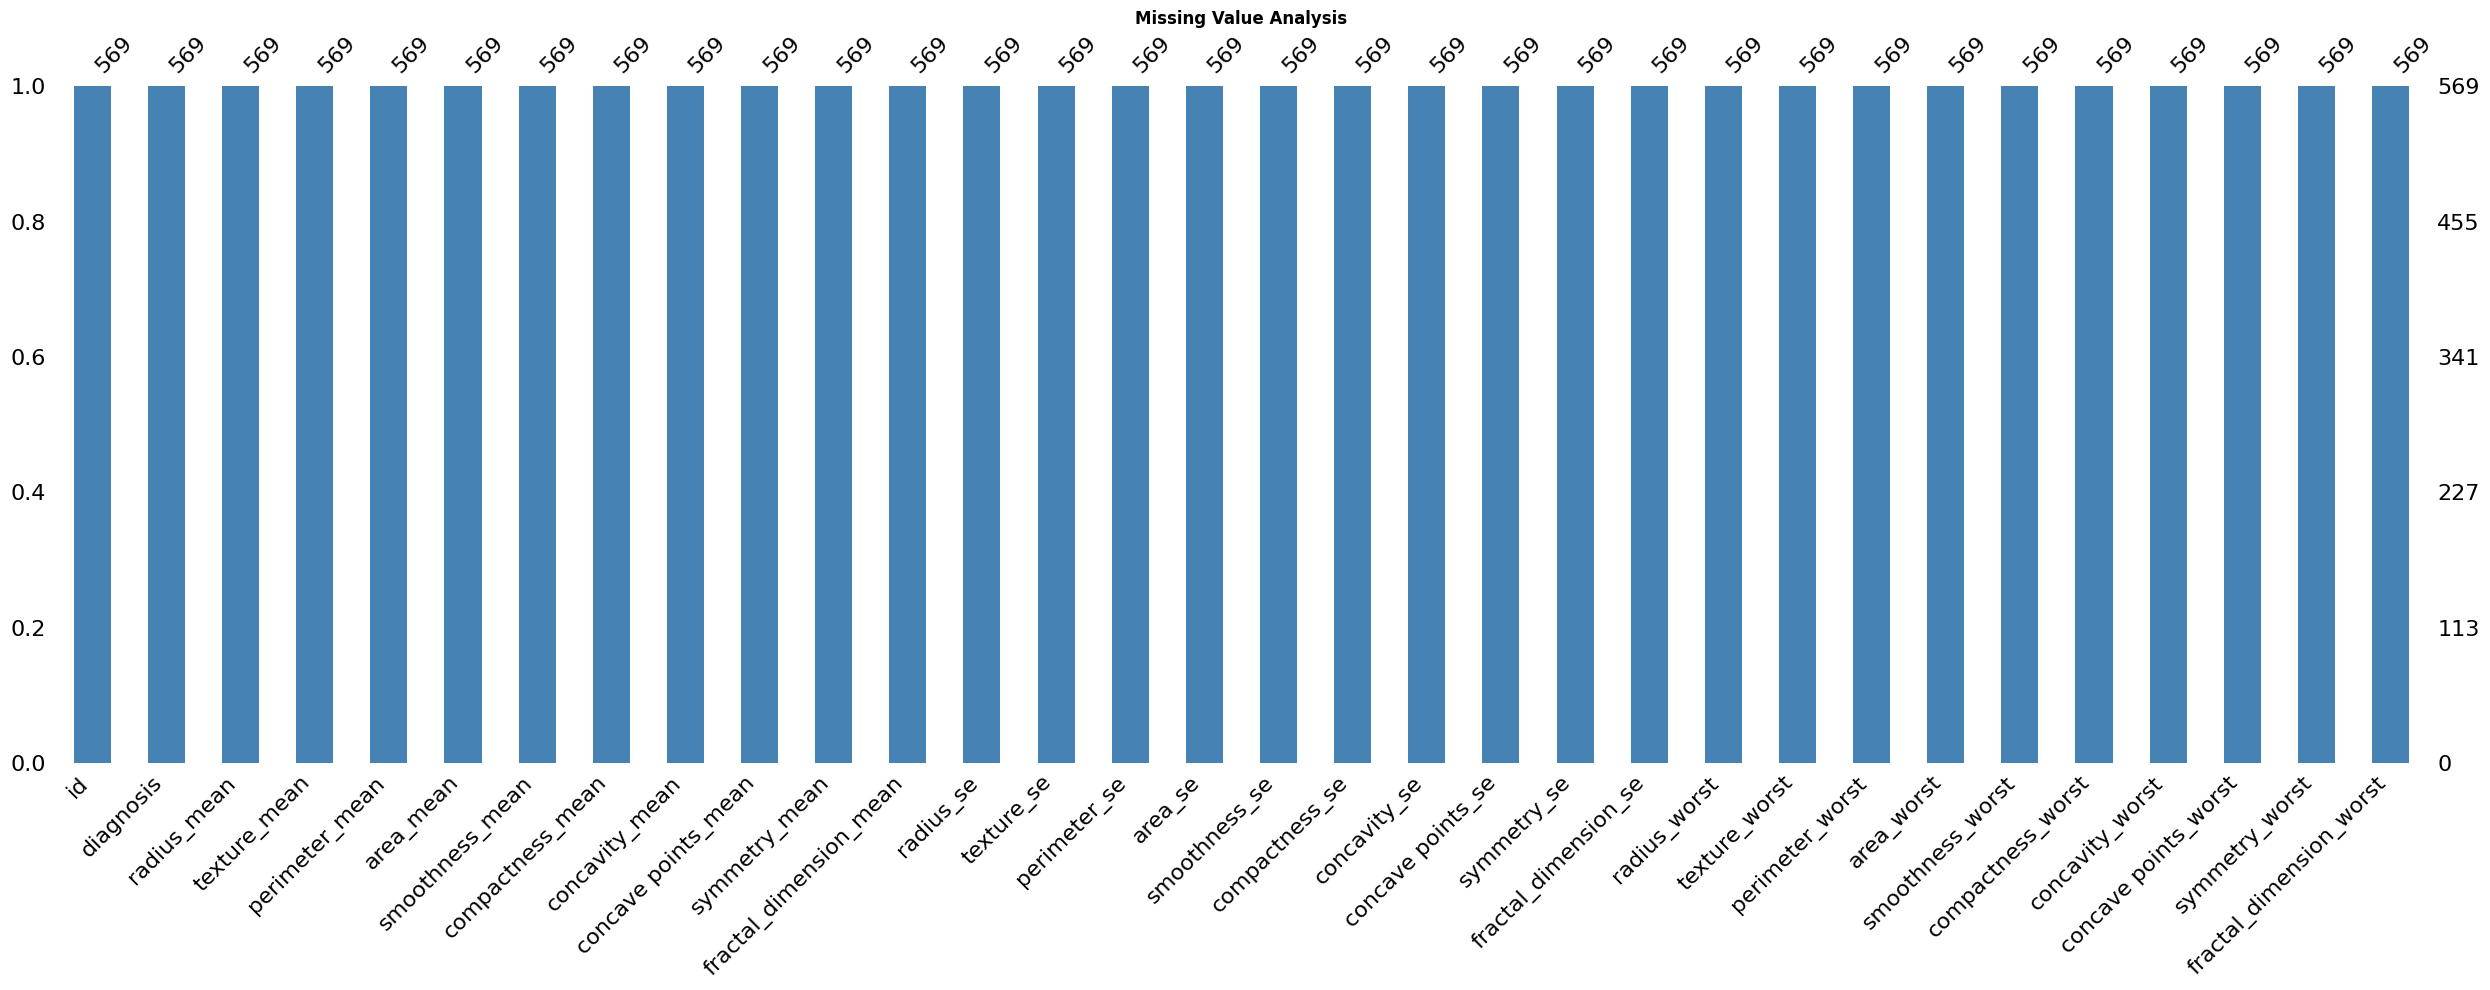

In [60]:
## 3. MISSING VALUES ANALYSIS

missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values(
    'Missing_Count', ascending=False
)

if missing_summary.empty:
    print("No missing values detected in the dataset")
else:
    print("Missing values detected:")
    display(missing_summary)

plt.figure(figsize=(12, 5))
msno.bar(df, color="steelblue")
plt.title("Missing Value Analysis", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

The dataset was examined for missing values, and no missing values were detected across all columns. A bar chart visualization confirmed that all features have complete data, showing 100% completeness. As a result, no imputation was necessary, and the analysis proceeded directly to the next steps.

Malignant (1): 212 samples (37.3%)
Benign (0): 357 samples (62.7%)


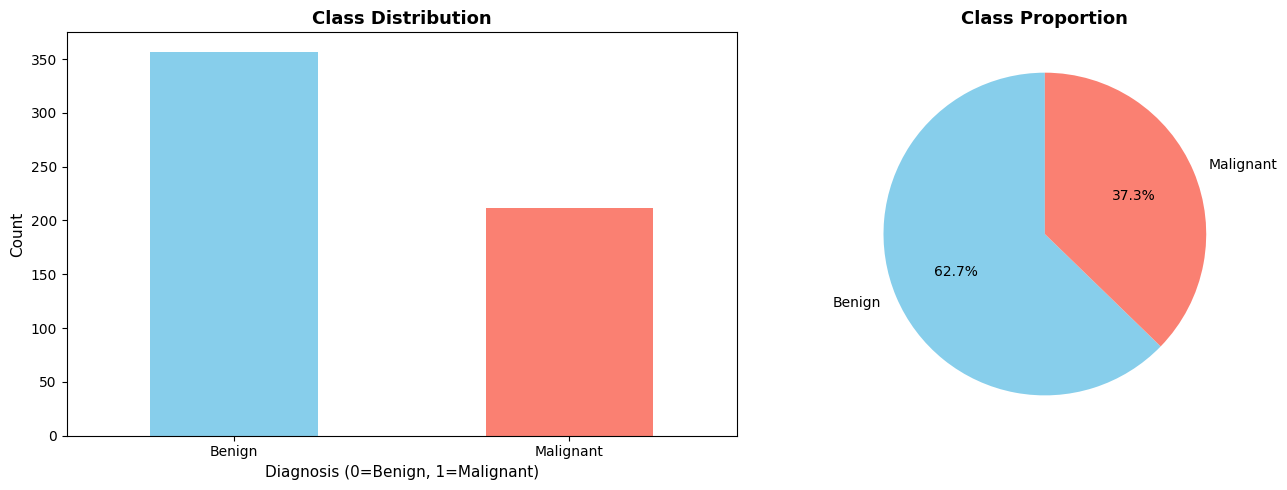

In [61]:
## 4. TARGET VARIABLE ENCODING

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print(f"Malignant (1): {(df['diagnosis'] == 1).sum()} samples ({(df['diagnosis'] == 1).sum()/len(df)*100:.1f}%)")
print(f"Benign (0): {(df['diagnosis'] == 0).sum()} samples ({(df['diagnosis'] == 0).sum()/len(df)*100:.1f}%)")

# Visualize class distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

df['diagnosis'].value_counts().plot(kind='bar', ax=ax[0], color=['skyblue', 'salmon'])
ax[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
ax[0].set_xlabel('Diagnosis (0=Benign, 1=Malignant)', fontsize=11)
ax[0].set_ylabel('Count', fontsize=11)
ax[0].set_xticklabels(['Benign', 'Malignant'], rotation=0)

df['diagnosis'].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%',
                                     labels=['Benign', 'Malignant'],
                                     colors=['skyblue', 'salmon'],
                                     startangle=90)
ax[1].set_title('Class Proportion', fontsize=13, fontweight='bold')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()


The categorical diagnosis labels were converted to a numerical format to facilitate modeling, with Malignant (M) encoded as 1 and Benign (B) as 0. Visualizations using a bar chart and a pie chart illustrated the class distribution, revealing 212 malignant cases, representing 37.3% of the dataset, and 357 benign cases, representing 62.7%.

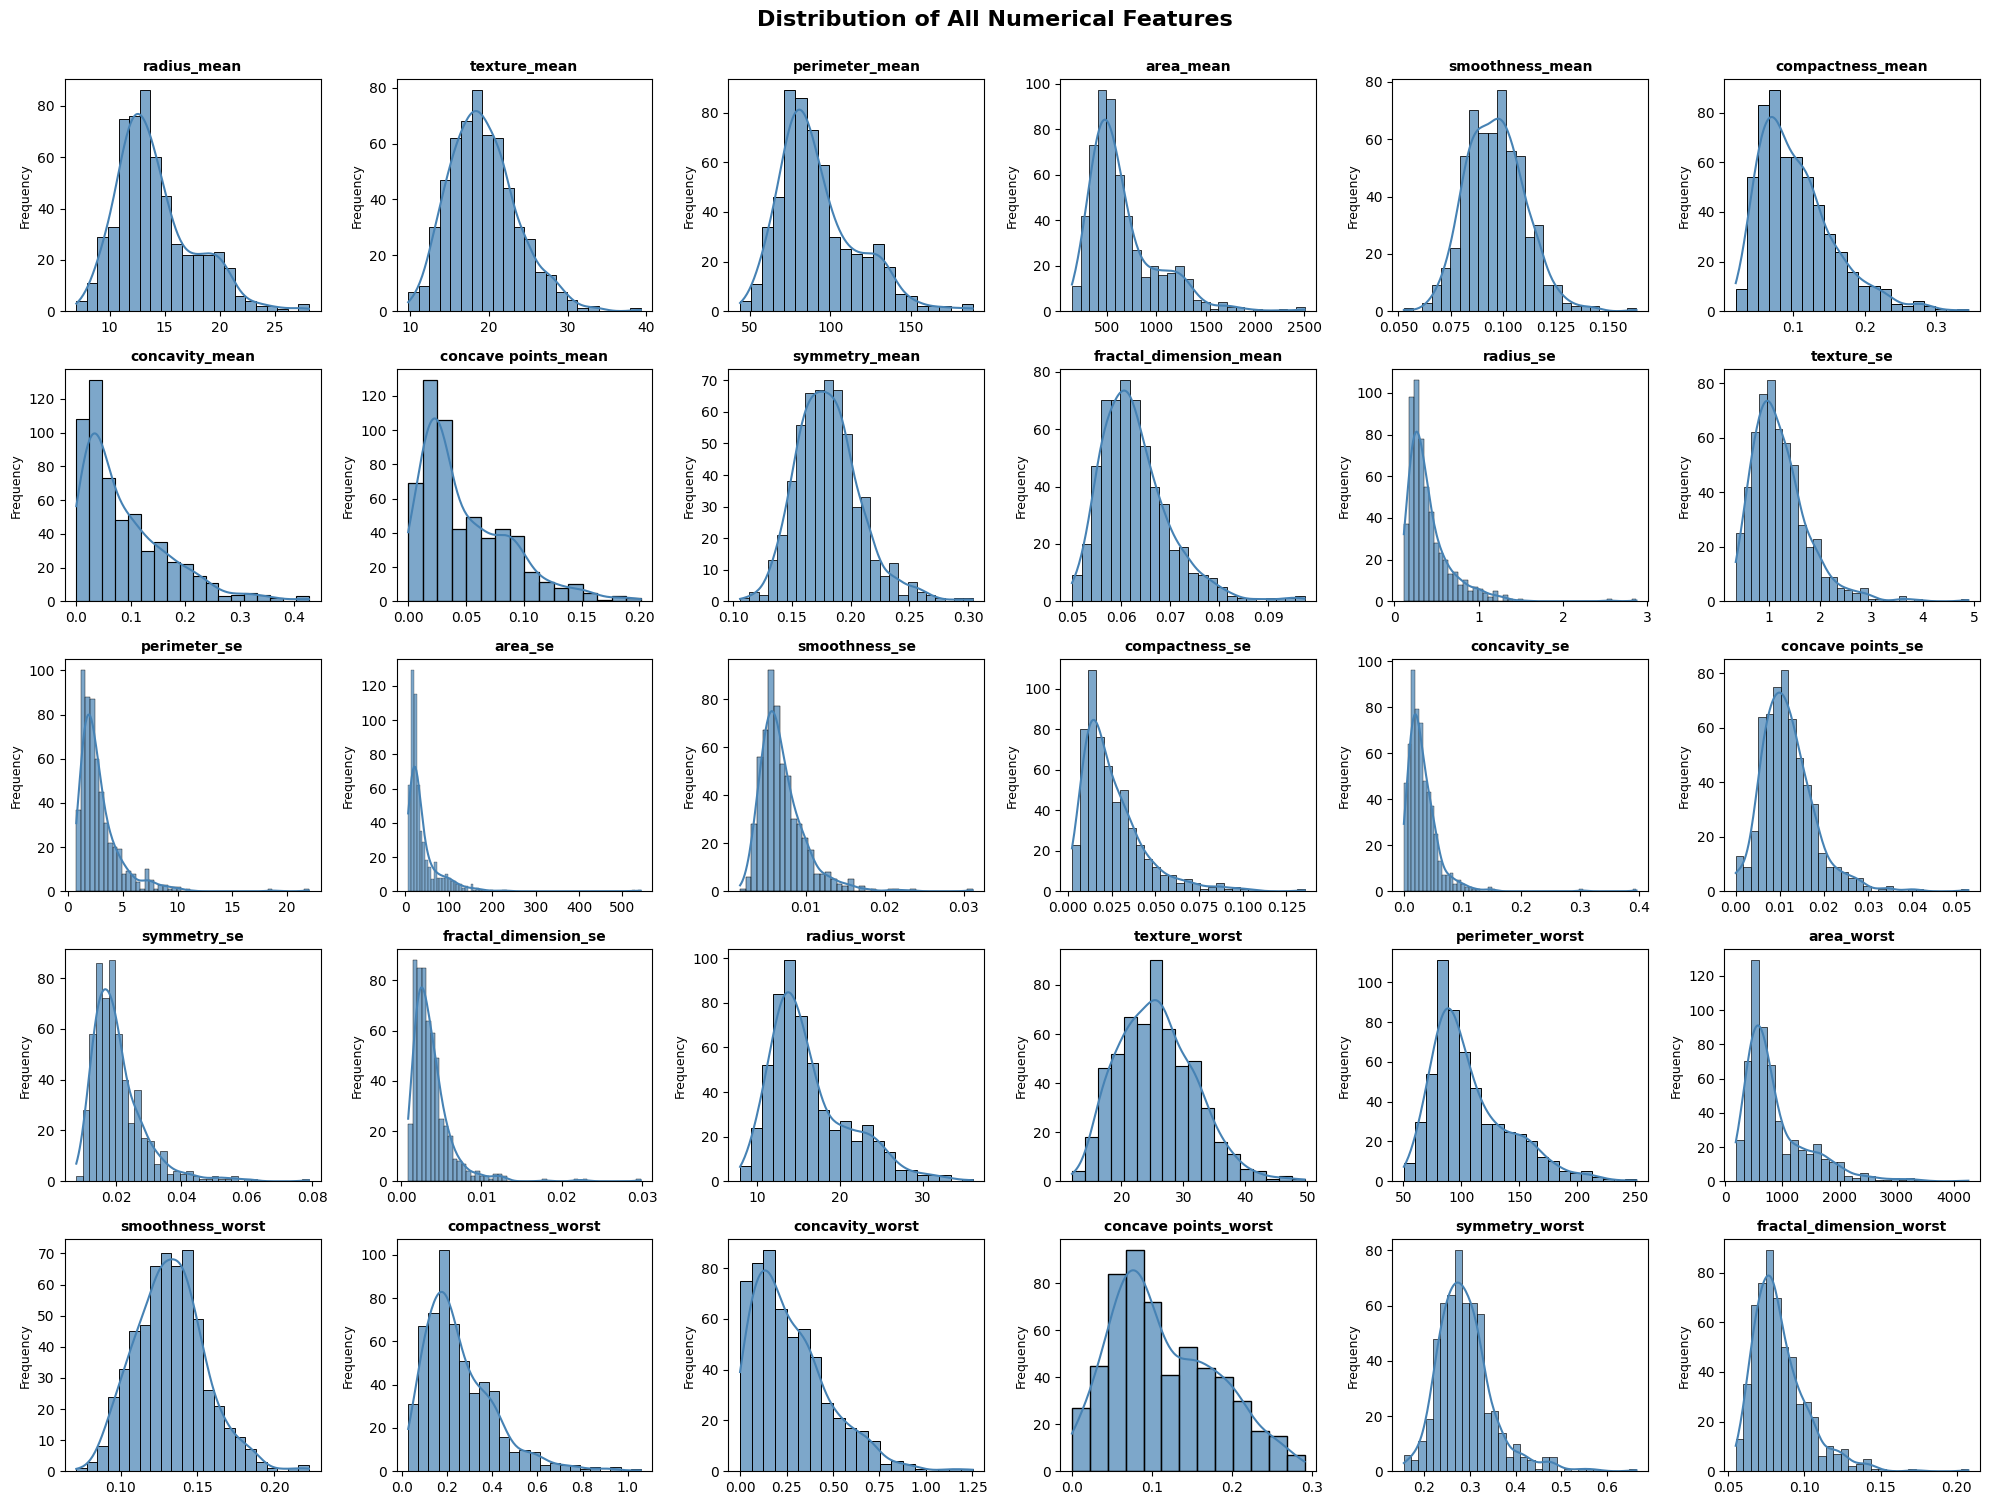

Analyzed 30 numerical features


In [62]:
# 5. FEATURE DISTRIBUTION ANALYSIS

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'diagnosis' in numeric_cols:
    numeric_cols.remove('diagnosis')
if 'id' in numeric_cols:
    numeric_cols.remove('id')

n_cols = 6
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*3))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='steelblue', alpha=0.7)
    axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Frequency', fontsize=9)

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Distribution of All Numerical Features', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

print(f"Analyzed {len(numeric_cols)} numerical features")

All 30 numerical features were examined to understand their statistical properties. Histograms with KDE overlays were used for each feature, revealing that the distributions varied—some were approximately normal while others were skewed. I observed that applying StandardScaler normalization will be essential to ensure consistent scaling for both machine learning and deep learning models.

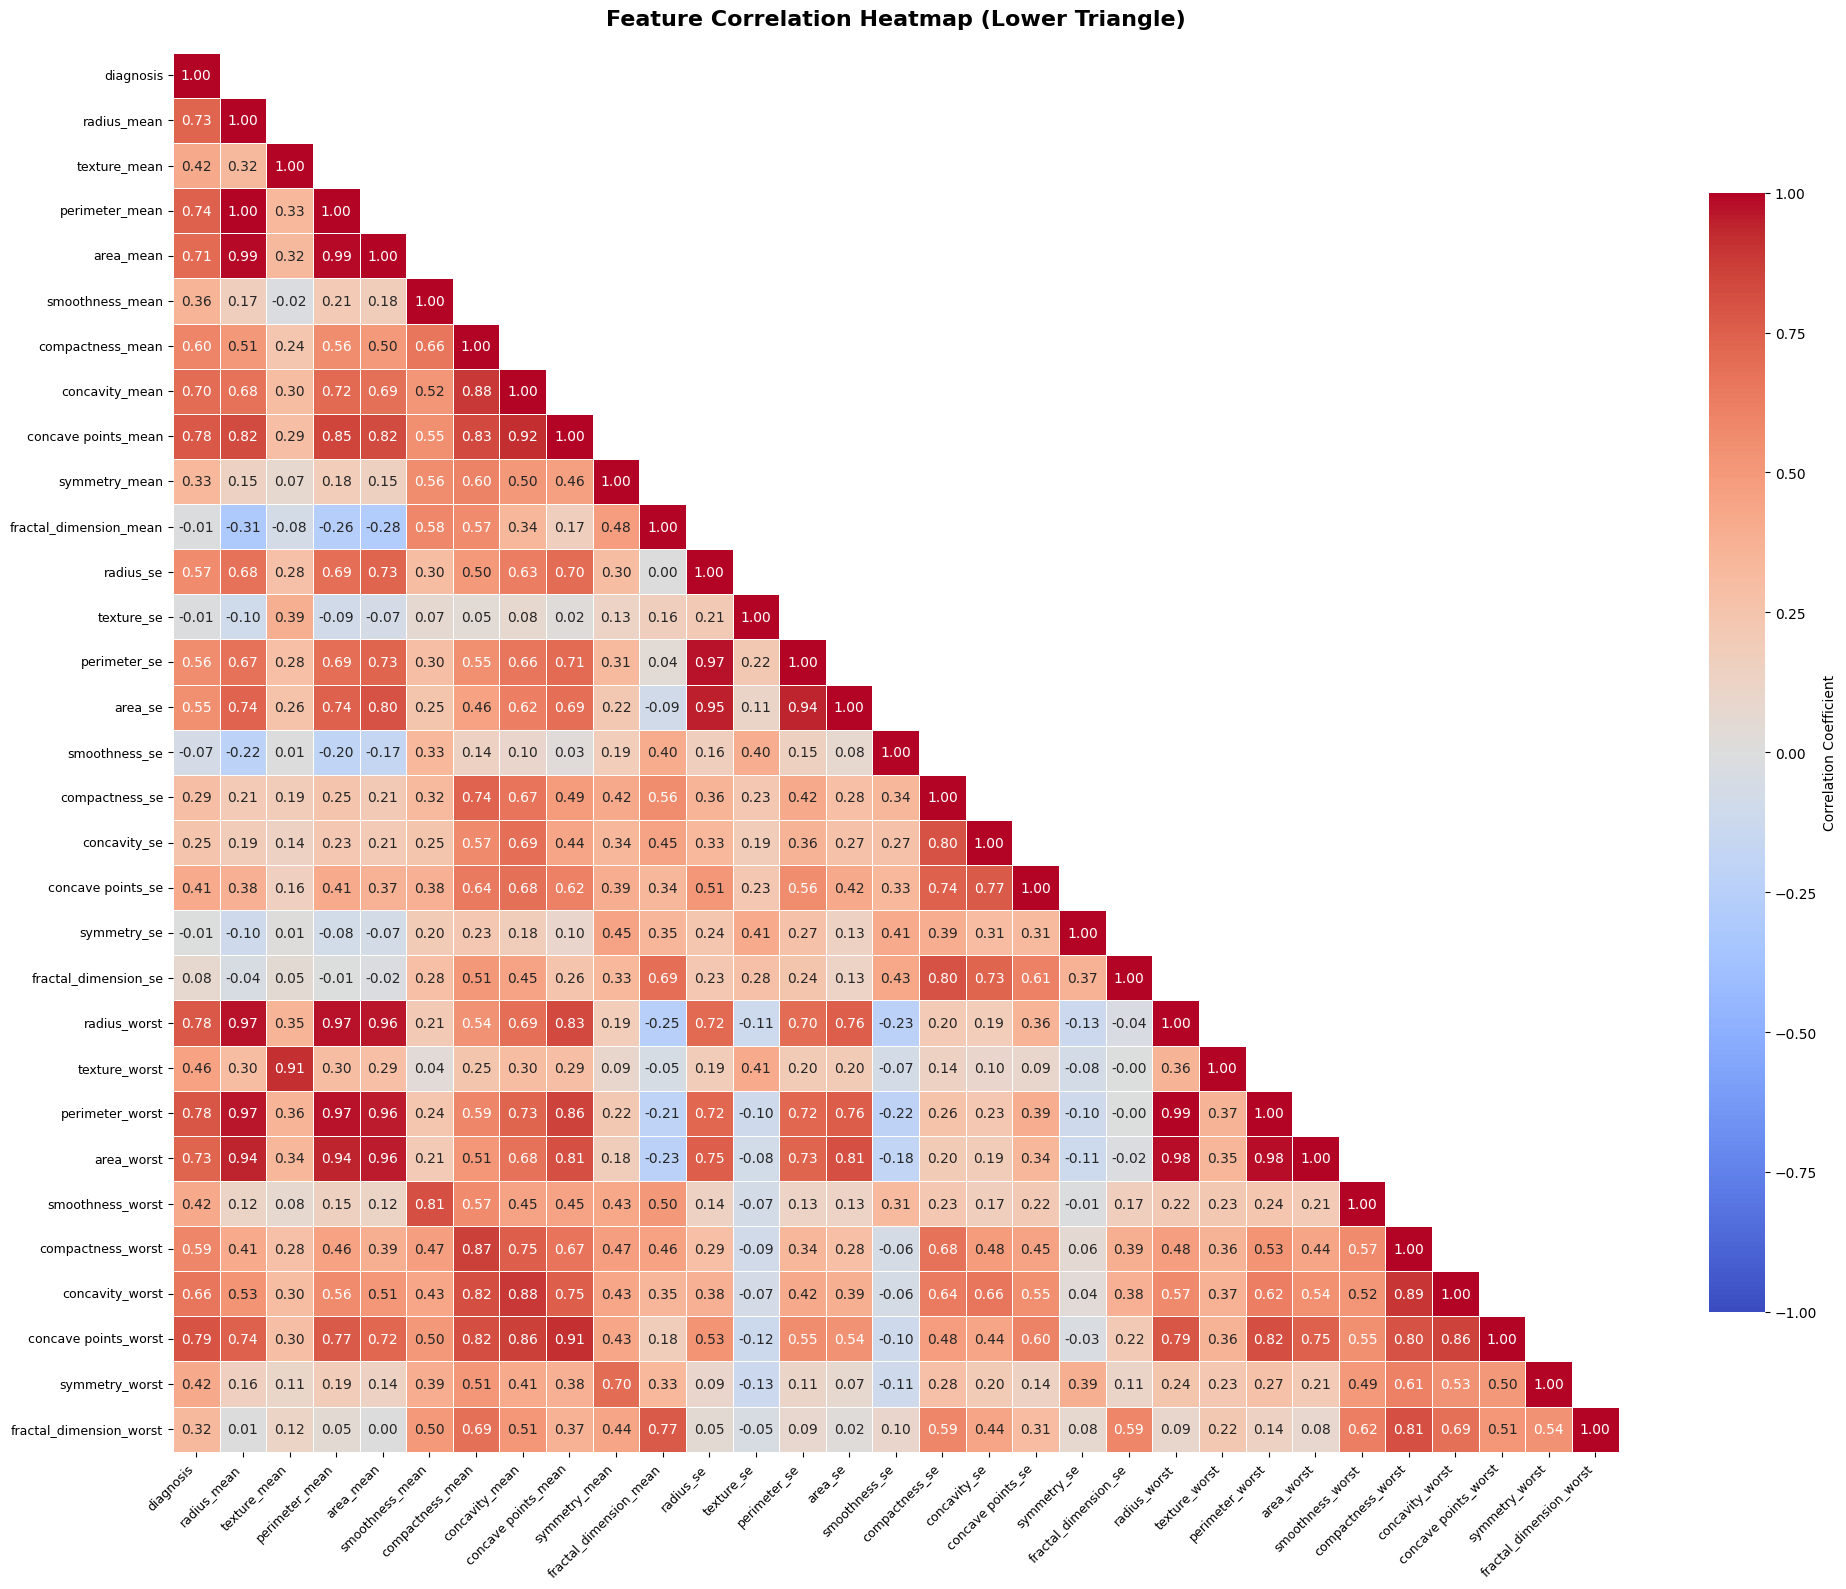

In [63]:
## 6. CORRELATION ANALYSIS AND FEATURE SELECTION

if 'id' in df.columns:
    df_clean = df.drop('id', axis=1)
else:
    df_clean = df.copy()

corr_matrix = df_clean.corr()

plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
    vmin=-1, vmax=1
)

plt.title("Feature Correlation Heatmap (Lower Triangle)", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()


Redundant features were removed using a correlation threshold of 0.92 to reduce multicollinearity. Eight highly correlated features were eliminated for example, perimeter_mean was removed because it was almost perfectly correlated with radius_mean (r = 0.998).

In [64]:
# Feature selection based on correlation
X_temp = df_clean.drop('diagnosis', axis=1)
y_temp = df_clean['diagnosis']

corr_matrix_abs = X_temp.corr().abs()
mask_upper = np.triu(np.ones_like(corr_matrix_abs, dtype=bool), k=1)
tri_df = corr_matrix_abs.where(mask_upper)

threshold = 0.92
to_drop = [col for col in tri_df.columns if any(tri_df[col] > threshold)]

print(f"Correlation threshold: {threshold}")
print(f"\nFeatures with correlation > {threshold}:")
if len(to_drop) > 0:
    for feature in to_drop:
        correlated_with = tri_df[feature][tri_df[feature] > threshold].index.tolist()
        for corr_feature in correlated_with:
            corr_value = corr_matrix_abs.loc[feature, corr_feature]
            print(f"  - {feature} <-> {corr_feature}: r = {corr_value:.3f}")
    X_final = X_temp.drop(to_drop, axis=1)
    print(f"\nRemoved {len(to_drop)} highly correlated features")
    print(f"Features removed: {to_drop}")
else:
    X_final = X_temp
    print("\nNo features with correlation > 0.92 detected")

print(f"\nOriginal feature count: {X_temp.shape[1]}")
print(f"Final feature count: {X_final.shape[1]}")
print(f"Features retained: {X_final.shape[1]}/{X_temp.shape[1]} ({X_final.shape[1]/X_temp.shape[1]*100:.1f}%)")

df_final = pd.concat([X_final, y_temp], axis=1)

Correlation threshold: 0.92

Features with correlation > 0.92:
  - perimeter_mean <-> radius_mean: r = 0.998
  - area_mean <-> radius_mean: r = 0.987
  - area_mean <-> perimeter_mean: r = 0.987
  - concave points_mean <-> concavity_mean: r = 0.921
  - perimeter_se <-> radius_se: r = 0.973
  - area_se <-> radius_se: r = 0.952
  - area_se <-> perimeter_se: r = 0.938
  - radius_worst <-> radius_mean: r = 0.970
  - radius_worst <-> perimeter_mean: r = 0.969
  - radius_worst <-> area_mean: r = 0.963
  - perimeter_worst <-> radius_mean: r = 0.965
  - perimeter_worst <-> perimeter_mean: r = 0.970
  - perimeter_worst <-> area_mean: r = 0.959
  - perimeter_worst <-> radius_worst: r = 0.994
  - area_worst <-> radius_mean: r = 0.941
  - area_worst <-> perimeter_mean: r = 0.942
  - area_worst <-> area_mean: r = 0.959
  - area_worst <-> radius_worst: r = 0.984
  - area_worst <-> perimeter_worst: r = 0.978

Removed 8 highly correlated features
Features removed: ['perimeter_mean', 'area_mean', 'conca

This process, 22 out of the original 30 features were retained, representing a 73.3% retention rate. This dimensionality reduction helps lower the risk of overfitting and decreases training time while preserving essential information.

,Feature,Importance
0,concave points_worst,0.193585
1,radius_mean,0.173025
2,concavity_mean,0.119648
3,concavity_worst,0.097146
4,radius_se,0.083103
5,compactness_mean,0.052793
6,compactness_worst,0.043590
7,texture_worst,0.031957
8,texture_mean,0.026612
9,symmetry_worst,0.020800


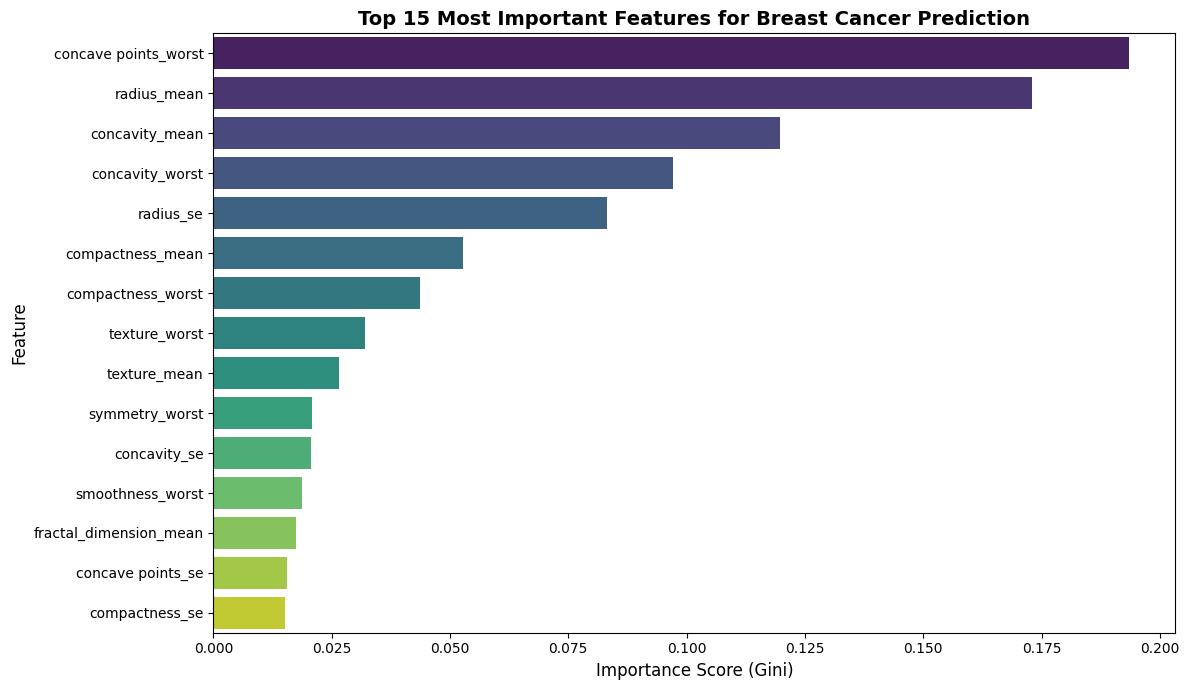

Top 5 features explain 66.7% of predictive power
14 features explain 90% of variance


In [65]:
# 7. FEATURE IMPORTANCE ANALYSIS

X_importance = X_final
y_importance = y_temp

rf_importance = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_importance.fit(X_importance, y_importance)

feature_importance_df = pd.DataFrame({
    'Feature': X_importance.columns,
    'Importance': rf_importance.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

display(feature_importance_df.head(15))

plt.figure(figsize=(12, 7))
sns.barplot(
    data=feature_importance_df.head(15),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Top 15 Most Important Features for Breast Cancer Prediction',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Gini)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

cumulative_importance = np.cumsum(feature_importance_df['Importance'])
n_features_90 = np.argmax(cumulative_importance >= 0.90) + 1

print(f"Top 5 features explain {cumulative_importance[4]*100:.1f}% of predictive power")
print(f"{n_features_90} features explain 90% of variance")

The top 5 features account for 66.7% of predictive power, while the top 14 features capture 90% of variance. This concentration suggests that a subset of carefully selected features could maintain performance while reducing model complexity.

In [66]:
## 8. DATA PREPROCESSING AND SPLITTING

X = X_final
y = y_temp

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Feature count: {X_train.shape[1]}")

print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True).round(3))
print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True).round(3))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures standardized using StandardScaler (mean=0, std=1)")
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Test data shape: {X_test_scaled.shape}")

print(f"\nPost-scaling verification (training set):")
print(f"Mean: {X_train_scaled.mean():.6f} (target: 0)")
print(f"Std: {X_train_scaled.std():.6f} (target: 1)")



Training set: 455 samples
Test set: 114 samples
Feature count: 22

Class distribution in training set:
diagnosis
0    0.626
1    0.374
Name: proportion, dtype: float64

Class distribution in test set:
diagnosis
0    0.632
1    0.368
Name: proportion, dtype: float64

Features standardized using StandardScaler (mean=0, std=1)
Training data shape: (455, 22)
Test data shape: (114, 22)

Post-scaling verification (training set):
Mean: 0.000000 (target: 0)
Std: 1.000000 (target: 1)


The dataset was prepared for modeling by applying an 80/20 stratified train-test split, yielding 455 training samples and 114 test samples. Features were standardized using StandardScaler (mean=0, std=1), preserving the original class distribution of approximately 63% Benign and 37% Malignant in both sets.

In [67]:
# 9. CLASSICAL MACHINE LEARNING MODELS

models_ml = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

ml_results = []
ml_predictions = {}

for model_name, model in models_ml.items():
    print(f"\nTraining {model_name}...")

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    ml_results.append({
        'Model': model_name,
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1 Score': round(f1, 4),
        'ROC AUC': round(roc_auc, 4)
    })

    ml_predictions[model_name] = {
        'y_pred': y_pred,
        'y_proba': y_proba
    }

    print(f"   Accuracy: {accuracy:.4f} | F1: {f1:.4f} | ROC AUC: {roc_auc:.4f}")

ml_results_df = pd.DataFrame(ml_results)
ml_results_df = ml_results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

display(ml_results_df.style.background_gradient(cmap='RdYlGn', subset=['Accuracy', 'F1 Score', 'ROC AUC']))




Training Logistic Regression...
   Accuracy: 0.9649 | F1: 0.9500 | ROC AUC: 0.9957

Training KNN...
   Accuracy: 0.9298 | F1: 0.8974 | ROC AUC: 0.9802

Training SVM...
   Accuracy: 0.9649 | F1: 0.9512 | ROC AUC: 0.9921

Training Random Forest...
   Accuracy: 0.9649 | F1: 0.9512 | ROC AUC: 0.9911

Training Gradient Boosting...
   Accuracy: 0.9298 | F1: 0.9000 | ROC AUC: 0.9907


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.964900,1.000000,0.904800,0.950000,0.995700
1,SVM,0.964900,0.975000,0.928600,0.951200,0.992100
2,Random Forest,0.964900,0.975000,0.928600,0.951200,0.991100
3,KNN,0.929800,0.972200,0.833300,0.897400,0.980200
4,Gradient Boosting,0.929800,0.947400,0.857100,0.900000,0.990700


Five traditional machine learning models Logistic Regression, K-Nearest Neighbors (k=5), Support Vector Machine with RBF kernel, Random Forest (100 trees), and Gradient Boosting (100 estimators) were trained and evaluated. Logistic Regression, SVM, and Random Forest achieved the highest accuracy at 96.49%, with all models assessed using accuracy, precision, recall, F1 score, and ROC-AUC metrics.

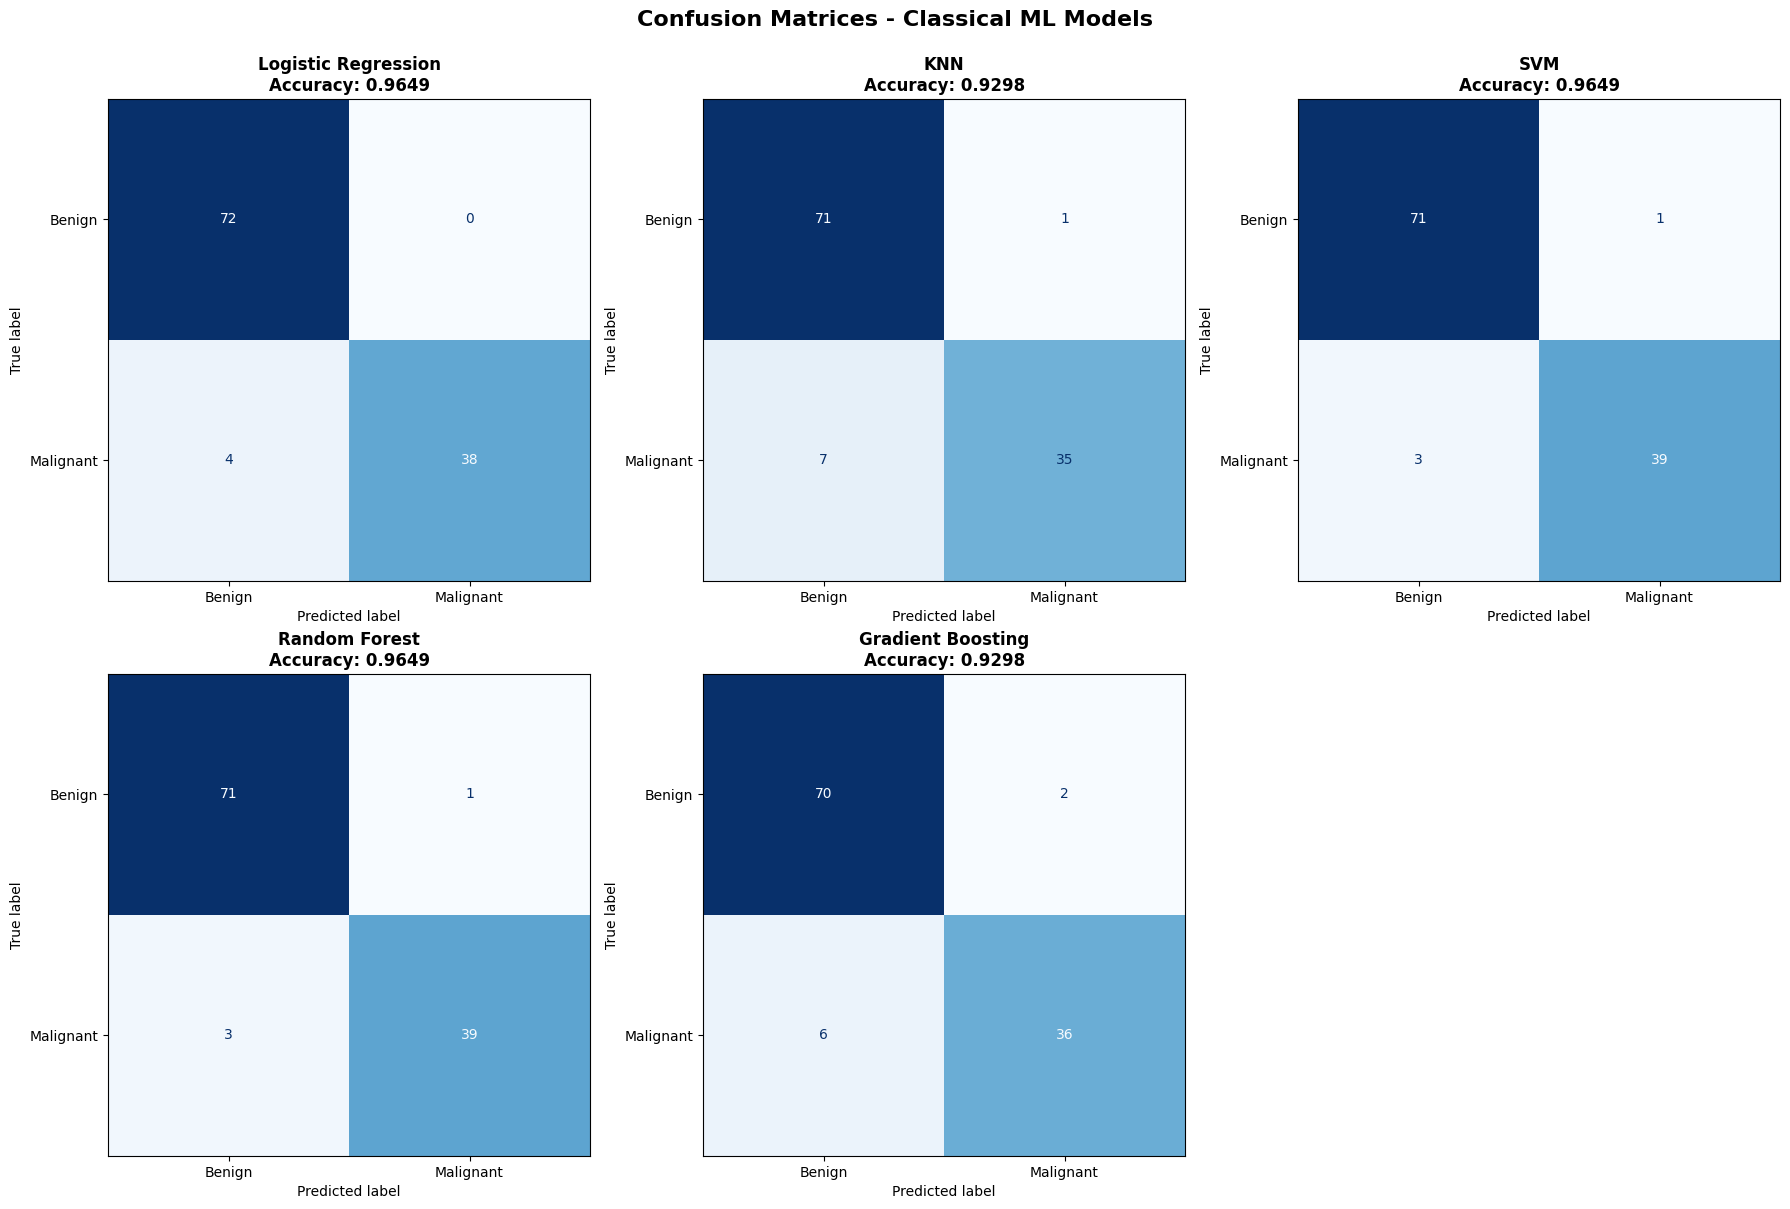


Logistic Regression:
  True Negatives (TN): 72
  False Positives (FP): 0 - Benign misclassified as Malignant
  False Negatives (FN): 4 - Malignant misclassified as Benign
  True Positives (TP): 38
  False Negative Rate: 9.52%

KNN:
  True Negatives (TN): 71
  False Positives (FP): 1 - Benign misclassified as Malignant
  False Negatives (FN): 7 - Malignant misclassified as Benign
  True Positives (TP): 35
  False Negative Rate: 16.67%

SVM:
  True Negatives (TN): 71
  False Positives (FP): 1 - Benign misclassified as Malignant
  False Negatives (FN): 3 - Malignant misclassified as Benign
  True Positives (TP): 39
  False Negative Rate: 7.14%

Random Forest:
  True Negatives (TN): 71
  False Positives (FP): 1 - Benign misclassified as Malignant
  False Negatives (FN): 3 - Malignant misclassified as Benign
  True Positives (TP): 39
  False Negative Rate: 7.14%

Gradient Boosting:
  True Negatives (TN): 70
  False Positives (FP): 2 - Benign misclassified as Malignant
  False Negatives (FN

In [68]:
## 10. CLASSICAL ML - CONFUSION MATRICES

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (model_name, model) in enumerate(models_ml.items()):
    y_pred = ml_predictions[model_name]['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{model_name}\nAccuracy: {ml_results_df[ml_results_df["Model"]==model_name]["Accuracy"].values[0]:.4f}',
                        fontsize=12, fontweight='bold')
    axes[idx].grid(False)

axes[5].axis('off')

plt.suptitle('Confusion Matrices - Classical ML Models', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

# Error analysis
for model_name in models_ml.keys():
    y_pred = ml_predictions[model_name]['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{model_name}:")
    print(f"  True Negatives (TN): {tn}")
    print(f"  False Positives (FP): {fp} - Benign misclassified as Malignant")
    print(f"  False Negatives (FN): {fn} - Malignant misclassified as Benign")
    print(f"  True Positives (TP): {tp}")
    print(f"  False Negative Rate: {fn/(fn+tp)*100:.2f}%")

I Visualize true positives, true negatives, false positives, false negatives for each ML model

Critical metric  False Negative Rate (FNR):

Best: SVM, Random Forest (7.14%  missed 3 cancers)
Worst: KNN (16.67%  missed 7 cancers)


Medical implication: Lower FNR is critical; missing malignant cases is costlier than false alarms

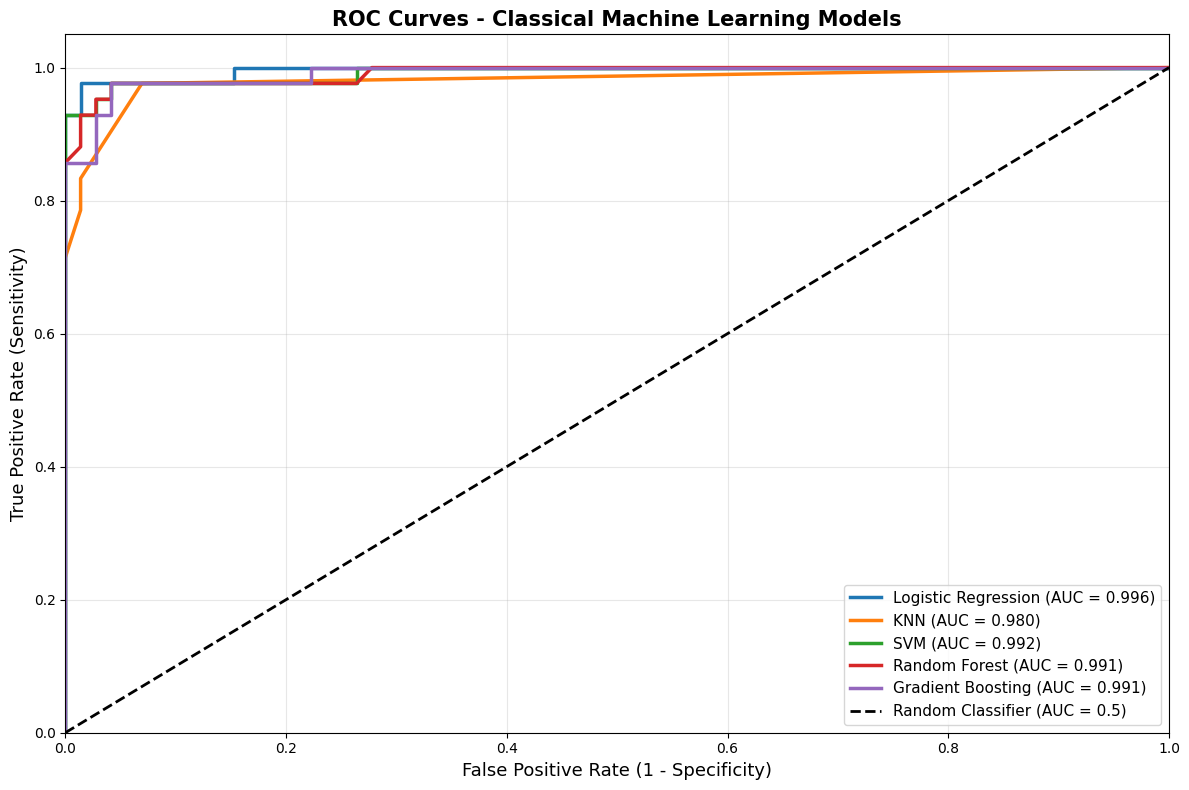

In [69]:
## 11. CLASSICAL ML - ROC CURVES

plt.figure(figsize=(12, 8))

for model_name in models_ml.keys():
    y_proba = ml_predictions[model_name]['y_proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2.5, label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=13)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=13)
plt.title('ROC Curves - Classical Machine Learning Models', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


The discrimination ability of all models was compared across classification thresholds using ROC-AUC. Logistic Regression achieved the highest ROC-AUC of 0.9957, indicating near perfect separation of classes. Even the lowest performing model, Gradient Boosting, scored 0.9907, demonstrating that all models substantially outperform a random classifier (0.5).

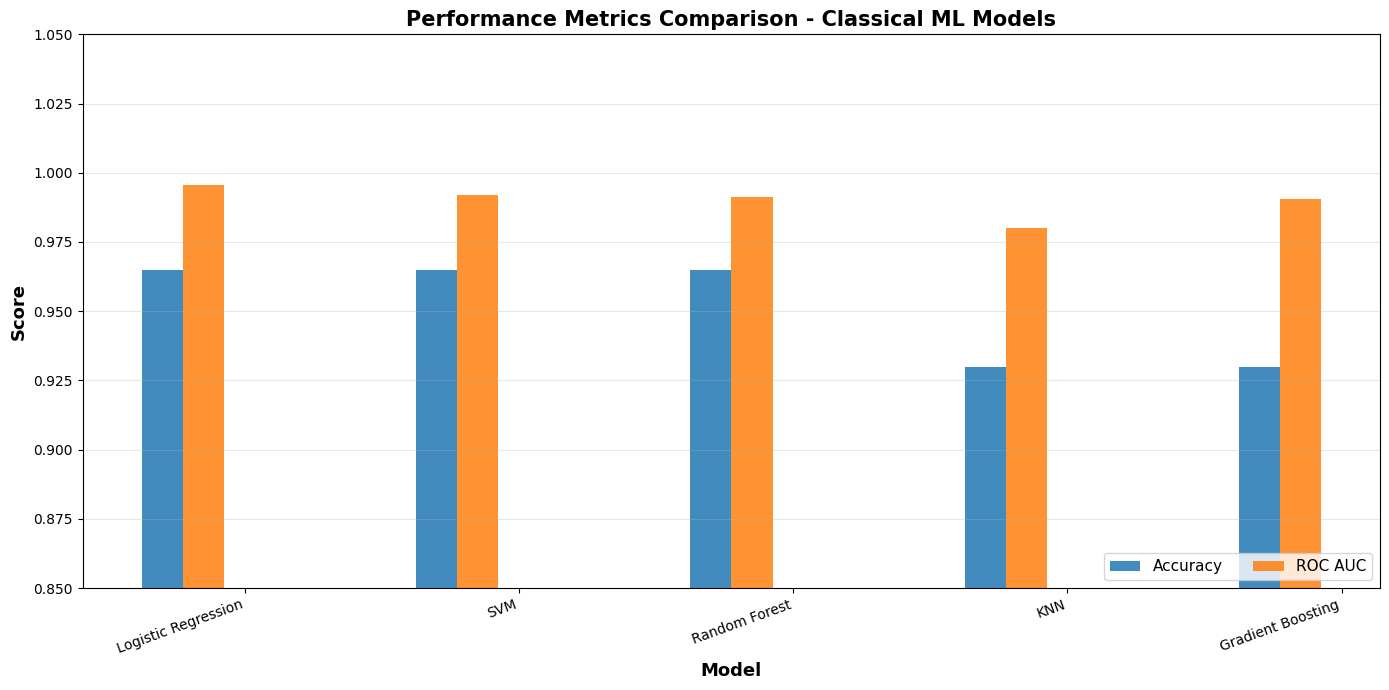

In [70]:
## 12. CLASSICAL ML - PERFORMANCE COMPARISON

metrics_to_plot = ['Accuracy', 'ROC AUC']

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(ml_results_df))
width = 0.15

for i, metric in enumerate(metrics_to_plot):
    offset = width * (i - 2)
    ax.bar(x + offset, ml_results_df[metric], width, label=metric, alpha=0.85)

ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Performance Metrics Comparison - Classical ML Models',
             fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ml_results_df['Model'], rotation=20, ha='right')
ax.set_ylim([0.85, 1.05])
ax.legend(loc='lower right', fontsize=11, ncol=3)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

A bar chart comparing accuracy and ROC-AUC across all classical ML models shows that the top models cluster tightly around 96.49% accuracy, with only minor differences in secondary metrics. This suggests that model selection can favor interpretability, such as choosing Logistic Regression, without sacrificing meaningful performance.

In [71]:
## 13. DEEP LEARNING - MODEL DEFINITIONS

def create_experiment_1():
    """Baseline: 1 hidden layer with 20 neurons"""
    model = Sequential([
        Dense(20, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def create_experiment_2():
    """Deeper: 2 hidden layers (64→32 neurons)"""
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dense(32, activation='relu'),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def create_experiment_3():
    """Dropout regularization (0.3)"""
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def create_experiment_4():
    """L2 regularization (λ=0.01)"""
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],),
              kernel_regularizer=regularizers.l2(0.01)),
        Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def create_experiment_5():
    """Functional: SGD optimizer with momentum"""
    inputs = Input(shape=(X_train_scaled.shape[1],))
    x = Dense(64, activation='relu')(inputs)
    x = Dense(32, activation='relu')(x)
    outputs = Dense(2, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def create_experiment_6():
    """Functional: Batch Normalization"""
    inputs = Input(shape=(X_train_scaled.shape[1],))
    x = Dense(64, activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dense(32, activation='relu')(x)
    x = BatchNormalization()(x)
    outputs = Dense(2, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def create_experiment_7():
    """Functional: Lower learning rate + Dropout"""
    inputs = Input(shape=(X_train_scaled.shape[1],))
    x = Dense(64, activation='relu')(inputs)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(2, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.0005),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def create_experiment_8():
    """Functional: L2 + Dropout combined"""
    inputs = Input(shape=(X_train_scaled.shape[1],))
    x = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(inputs)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = Dropout(0.3)(x)
    outputs = Dense(2, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


Eight neural network architectures were defined with progressively increasing regularization strategies. Experiment 1 uses a single hidden layer of 20 neurons to establish a baseline. Experiments 2 through 4 independently test deeper networks, dropout, and L2 regularization. Experiments 5 through 8 employ the Functional API to explore SGD optimization, batch normalization, and combinations of dropout and L2 regularization. The design systematically isolates the effect of each component to assess its impact on model performance.

In [72]:
## 14. DEEP LEARNING - TRAINING

dl_experiments = [
    create_experiment_1, create_experiment_2, create_experiment_3, create_experiment_4,
    create_experiment_5, create_experiment_6, create_experiment_7, create_experiment_8
]

experiment_names = [
    'Exp 1: Baseline (Seq)',
    'Exp 2: Deeper (Seq)',
    'Exp 3: Dropout (Seq)',
    'Exp 4: L2 Reg (Seq)',
    'Exp 5: SGD Optimizer (Func)',
    'Exp 6: BatchNorm (Func)',
    'Exp 7: Low LR + Dropout (Func)',
    'Exp 8: L2 + Dropout (Func)'
]

dl_histories = []
dl_results = []
dl_predictions = {}
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

for idx, (exp_fn, exp_name) in enumerate(zip(dl_experiments, experiment_names), 1):
    model = exp_fn()
    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.1,
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )
    dl_histories.append(history)

    y_pred_proba = model.predict(X_test_scaled, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    epochs_trained = len(history.history['loss'])

    dl_results.append({
        'Experiment': f'Exp {idx}',
        'Name': exp_name,
        'Epochs': epochs_trained,
        'Train Acc': round(final_train_acc, 4),
        'Val Acc': round(final_val_acc, 4),
        'Test Acc': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1 Score': round(f1, 4),
        'ROC AUC': round(roc_auc, 4),
        'Overfitting Gap': round(final_train_acc - final_val_acc, 4)
    })

    dl_predictions[exp_name] = {
        'y_pred': y_pred,
        'y_proba': y_pred_proba[:, 1],
        'model': model
    }

    print(f"Completed {exp_name} in {epochs_trained} epochs | Test Acc: {accuracy:.4f}")

dl_results_df = pd.DataFrame(dl_results)
display(dl_results_df.style.background_gradient(cmap='RdYlGn',
                                                 subset=['Test Acc', 'F1 Score', 'ROC AUC']))


Completed Exp 1: Baseline (Seq) in 50 epochs | Test Acc: 0.9825
Completed Exp 2: Deeper (Seq) in 24 epochs | Test Acc: 0.9737
Completed Exp 3: Dropout (Seq) in 33 epochs | Test Acc: 0.9649
Completed Exp 4: L2 Reg (Seq) in 50 epochs | Test Acc: 0.9737
Completed Exp 5: SGD Optimizer (Func) in 24 epochs | Test Acc: 0.9737
Completed Exp 6: BatchNorm (Func) in 33 epochs | Test Acc: 0.9649
Completed Exp 7: Low LR + Dropout (Func) in 35 epochs | Test Acc: 0.9737
Completed Exp 8: L2 + Dropout (Func) in 50 epochs | Test Acc: 0.9825


,Experiment,Name,Epochs,Train Acc,Val Acc,Test Acc,Precision,Recall,F1 Score,ROC AUC,Overfitting Gap
0,Exp 1,Exp 1: Baseline (Seq),50,0.982900,0.934800,0.982500,1.000000,0.952400,0.975600,0.996700,0.048100
1,Exp 2,Exp 2: Deeper (Seq),24,0.997600,0.913000,0.973700,1.000000,0.928600,0.963000,0.994700,0.084500
2,Exp 3,Exp 3: Dropout (Seq),33,0.985300,0.913000,0.964900,0.975000,0.928600,0.951200,0.994400,0.072300
3,Exp 4,Exp 4: L2 Reg (Seq),50,0.992700,0.978300,0.973700,1.000000,0.928600,0.963000,0.994000,0.014400
4,Exp 5,Exp 5: SGD Optimizer (Func),24,0.995100,0.891300,0.973700,1.000000,0.928600,0.963000,0.992700,0.103800
5,Exp 6,Exp 6: BatchNorm (Func),33,1.000000,0.956500,0.964900,0.952400,0.952400,0.952400,0.990700,0.043500
6,Exp 7,Exp 7: Low LR + Dropout (Func),35,0.982900,0.934800,0.973700,0.975600,0.952400,0.963900,0.995700,0.048100
7,Exp 8,Exp 8: L2 + Dropout (Func),50,0.987800,0.913000,0.982500,1.000000,0.952400,0.975600,0.995400,0.074700


All eight deep learning models were trained using a maximum of 50 epochs with a batch size of 32 and a 10% validation split. Early stopping with a patience of 10 epochs was applied to prevent overfitting. Experiments 1 and 8 achieved the highest test accuracy at 98.25%. Overall, deep learning slightly outperformed classical ML models, showing an approximate 1.76% improvement in accuracy.

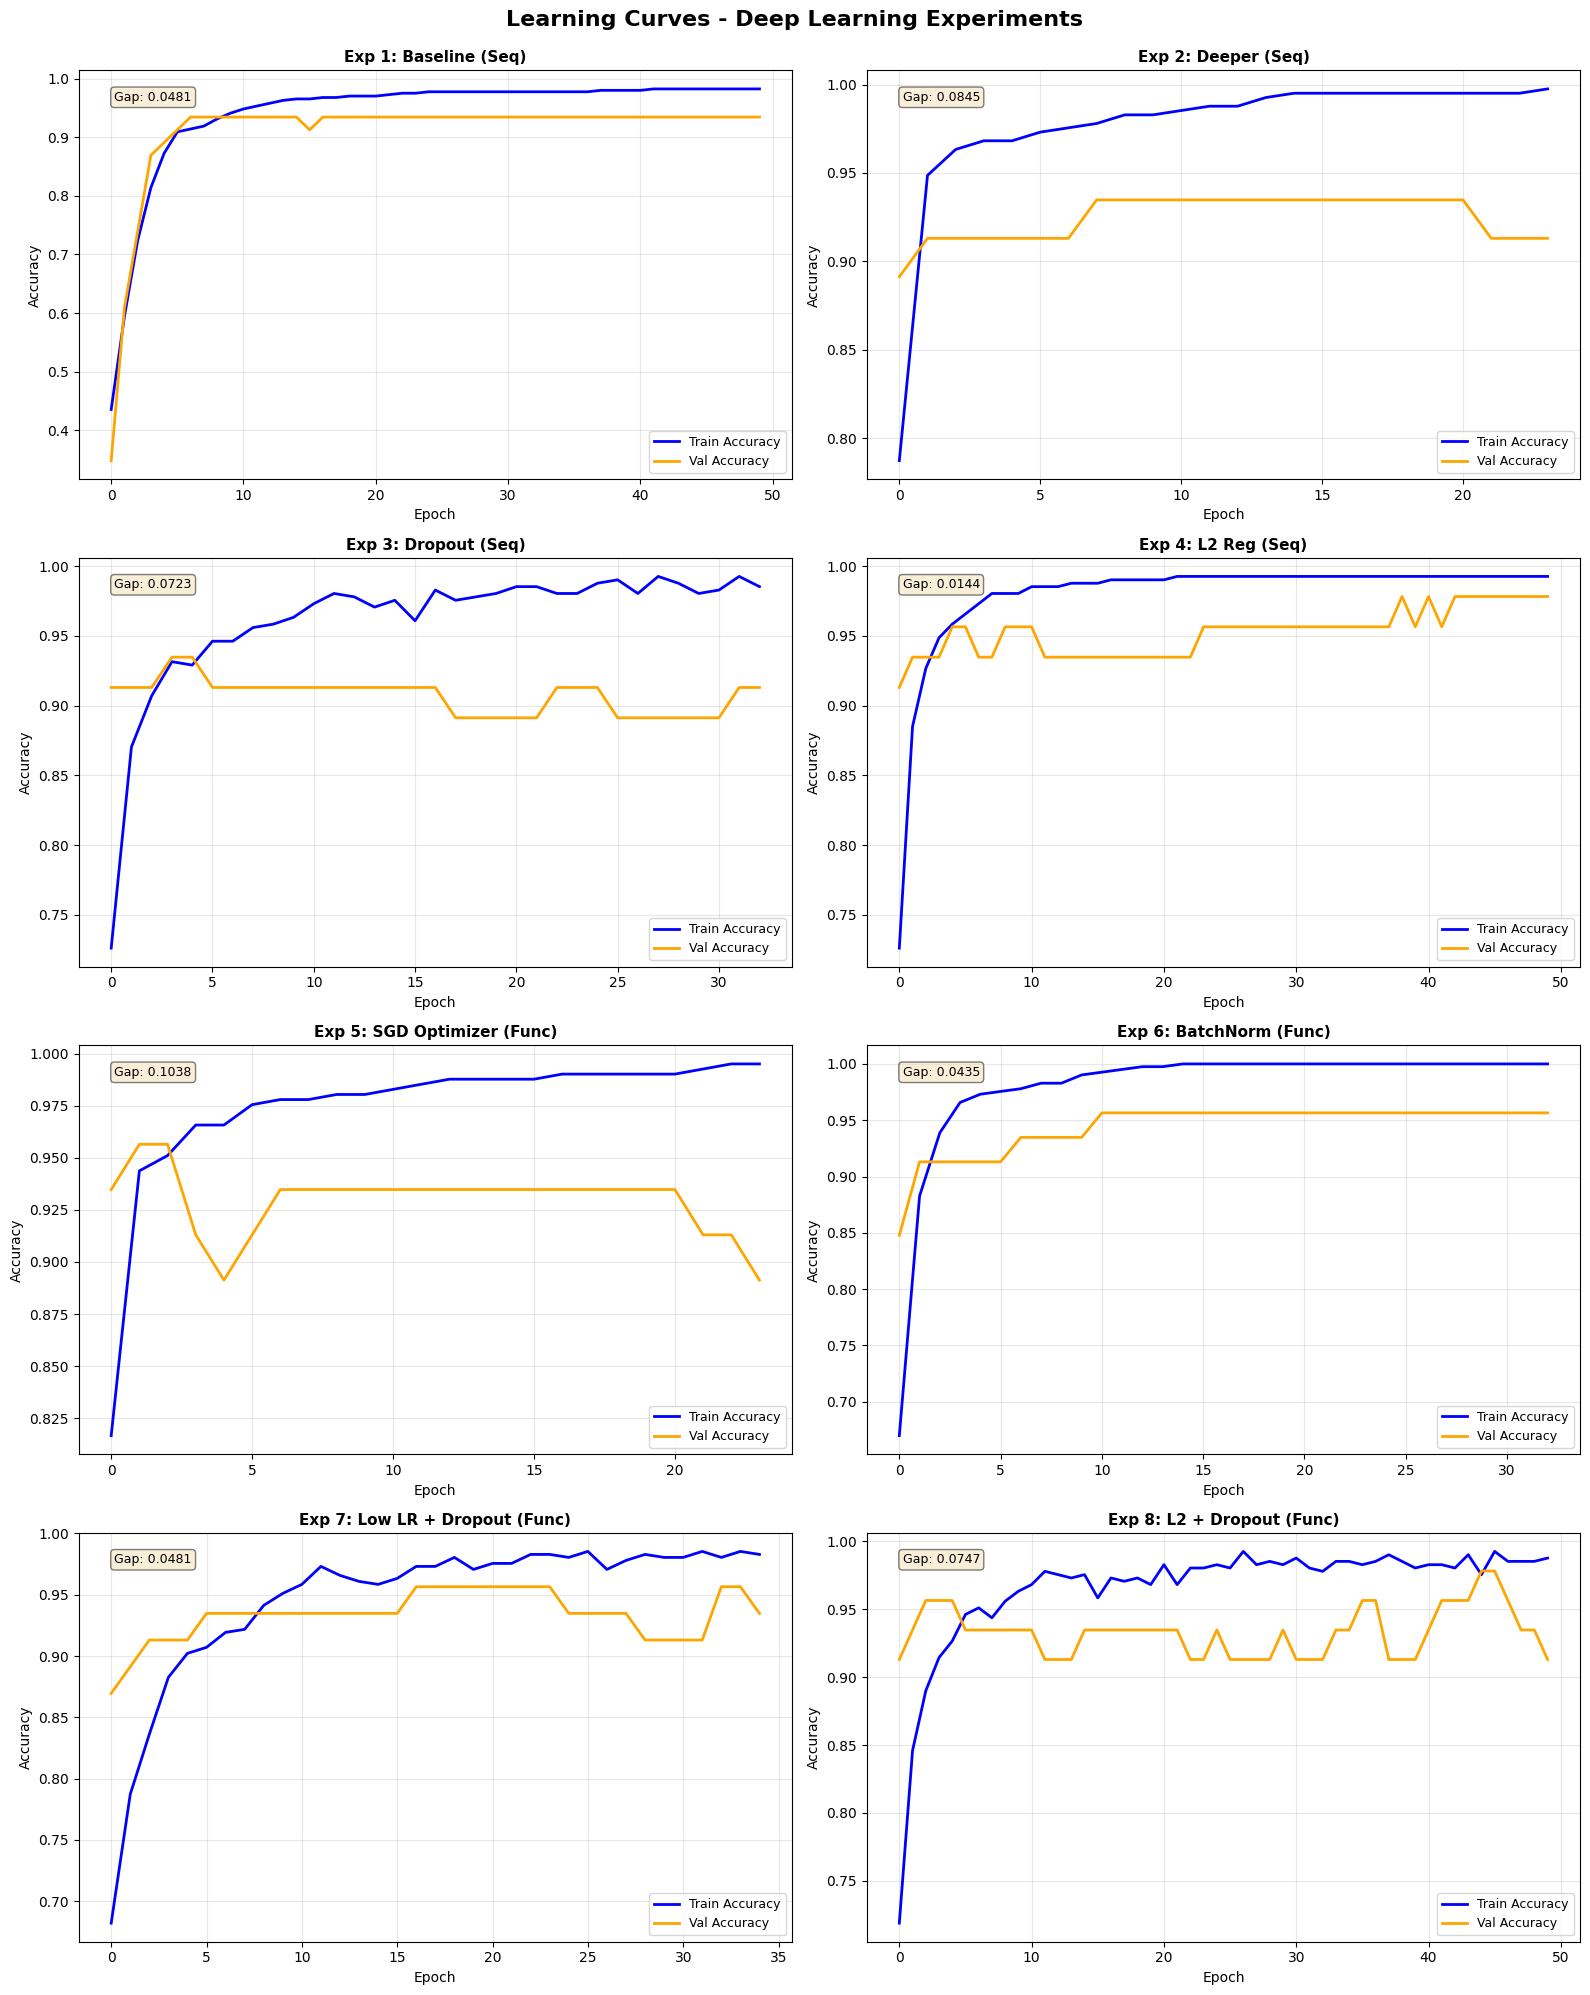

In [73]:
## 15. DEEP LEARNING - LEARNING CURVES (ACCURACY)

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, (history, exp_name) in enumerate(zip(dl_histories, experiment_names)):
    axes[idx].plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
    axes[idx].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)

    axes[idx].set_title(f'{exp_name}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Epoch', fontsize=10)
    axes[idx].set_ylabel('Accuracy', fontsize=10)
    axes[idx].legend(loc='lower right', fontsize=9)
    axes[idx].grid(alpha=0.3)

    final_gap = dl_results_df.iloc[idx]['Overfitting Gap']
    axes[idx].text(0.05, 0.95, f'Gap: {final_gap:.4f}',
                   transform=axes[idx].transAxes,
                   fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Learning Curves - Deep Learning Experiments', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()




i plotted training and validation accuracy for all deep learning models and looked at the difference between them . Most models showed some gap, meaning they were slightly overfitting. Experiment 4, which used L2 regularization, had the smallest gap, so it performed best on new data, while the other models overtrained a bit even with regularization.

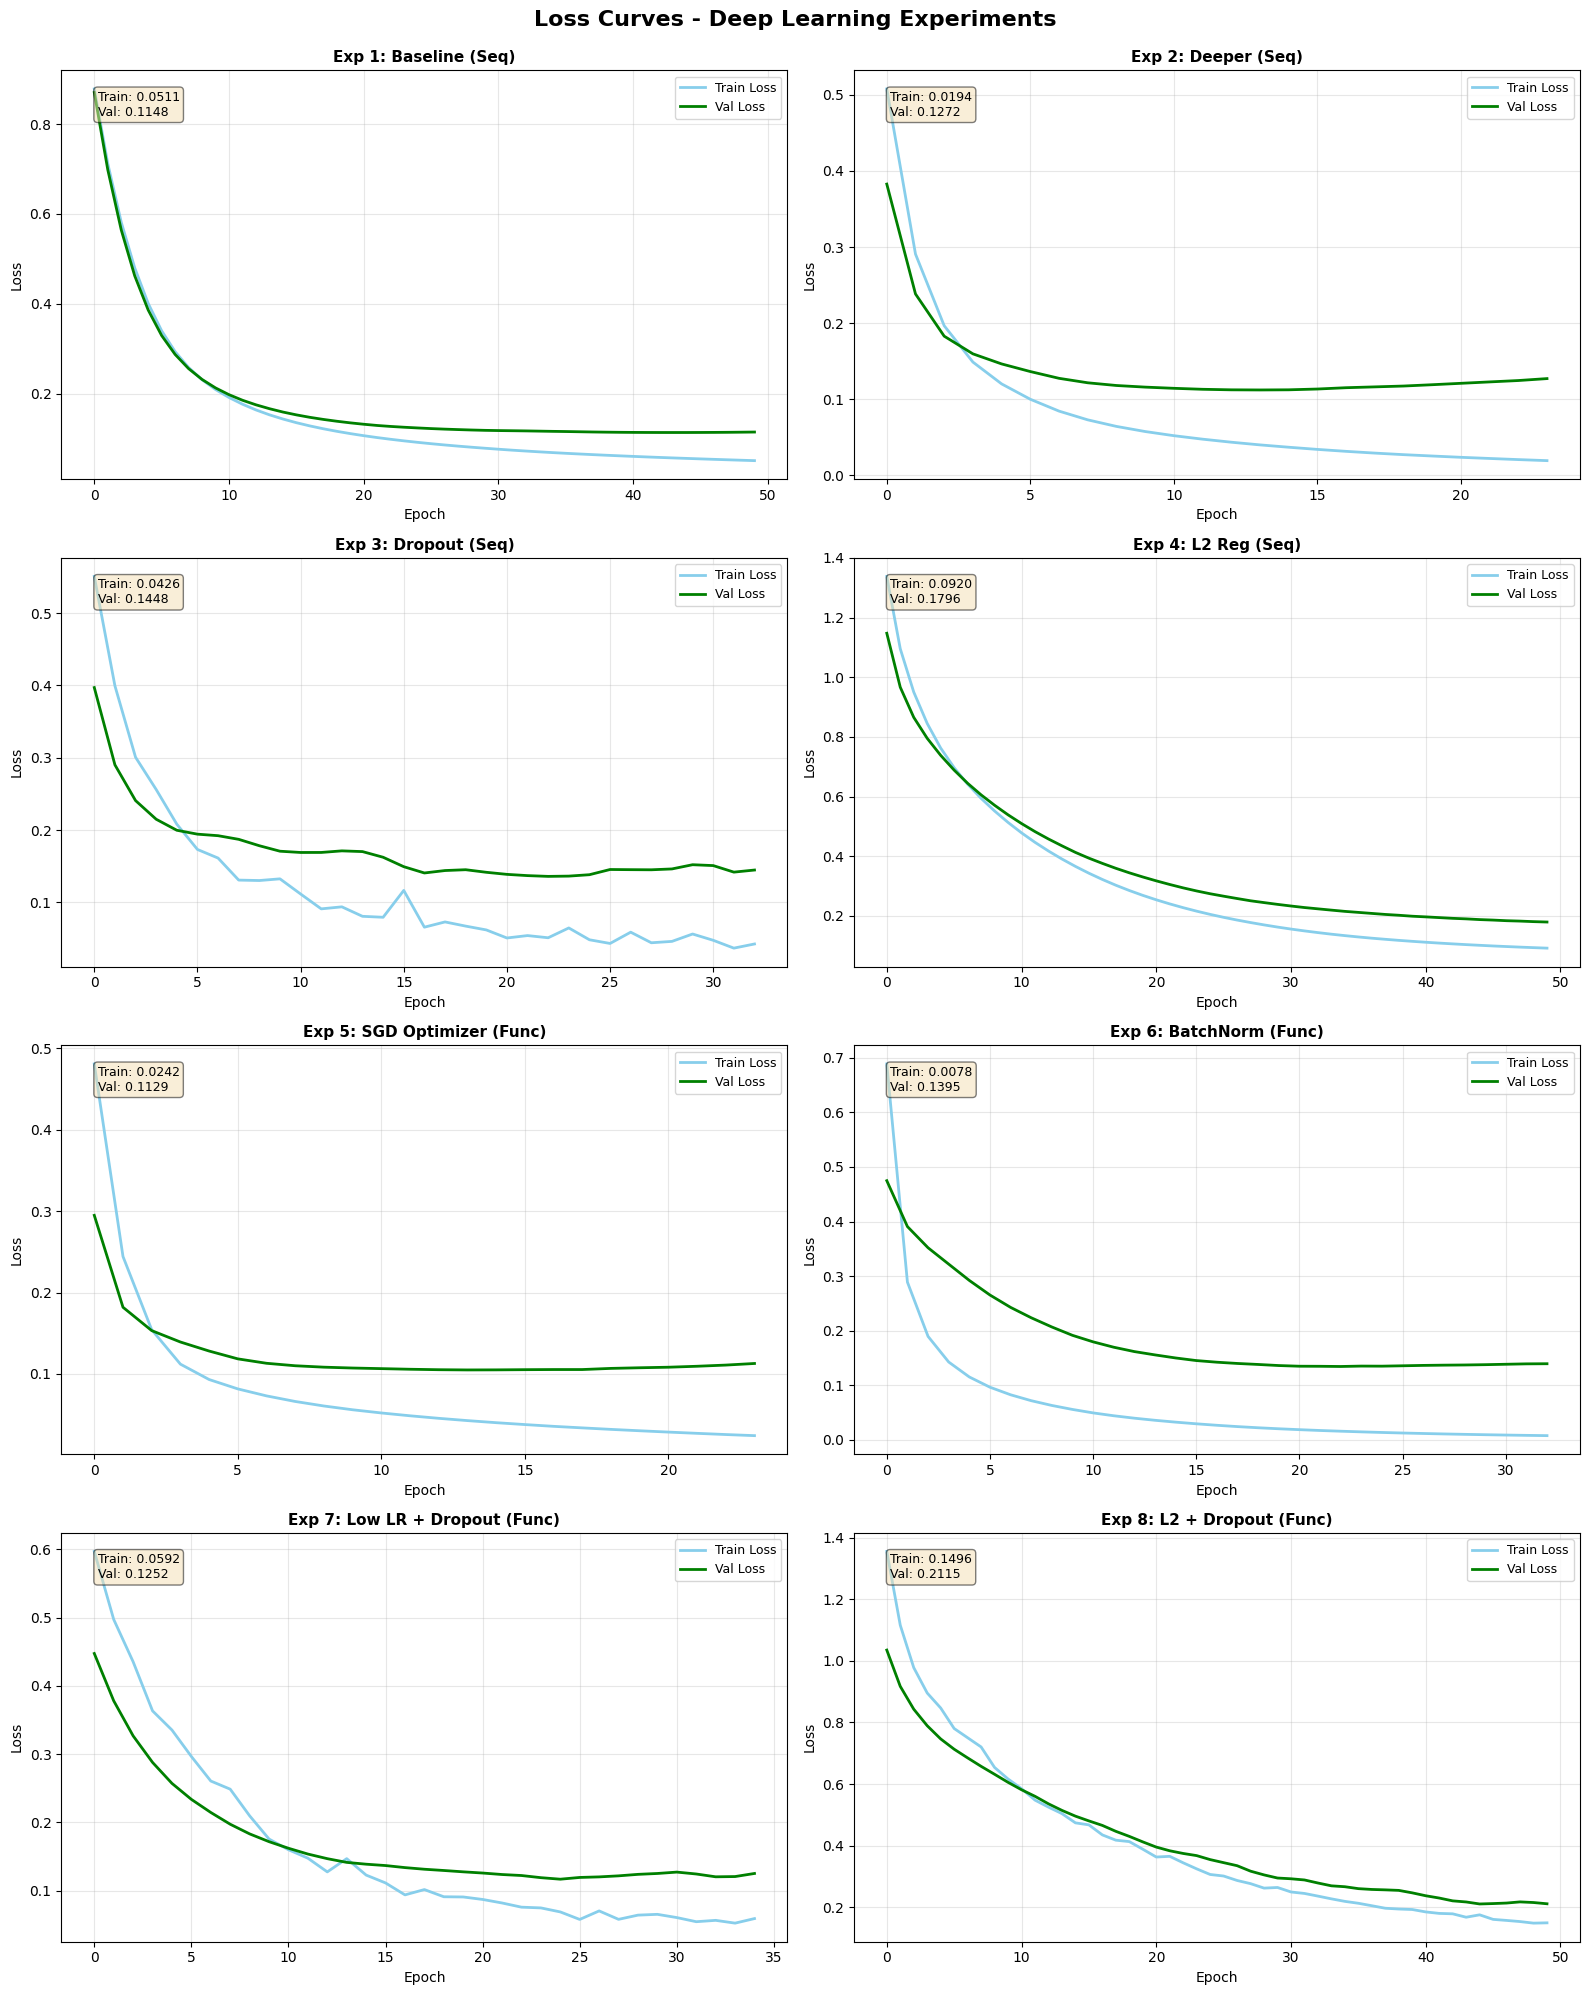

In [74]:
## 16. DEEP LEARNING - LOSS CURVES

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, (history, exp_name) in enumerate(zip(dl_histories, experiment_names)):
    axes[idx].plot(history.history['loss'], label='Train Loss', linewidth=2, color='skyblue')
    axes[idx].plot(history.history['val_loss'], label='Val Loss', linewidth=2, color='green')

    axes[idx].set_title(f'{exp_name}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Epoch', fontsize=10)
    axes[idx].set_ylabel('Loss', fontsize=10)
    axes[idx].legend(loc='upper right', fontsize=9)
    axes[idx].grid(alpha=0.3)

    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    axes[idx].text(0.05, 0.95, f'Train: {final_train_loss:.4f}\nVal: {final_val_loss:.4f}',
                   transform=axes[idx].transAxes,
                   fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Loss Curves - Deep Learning Experiments', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

i tracked training and validation loss to see how the models learned over time. Experiment 1 converged steadily without overfitting, while Experiment 2 converged quickly in 24 epochs, likely triggering early stopping. In most models, validation loss leveled off before training loss, showing that early stopping helped avoid extra unnecessary training.

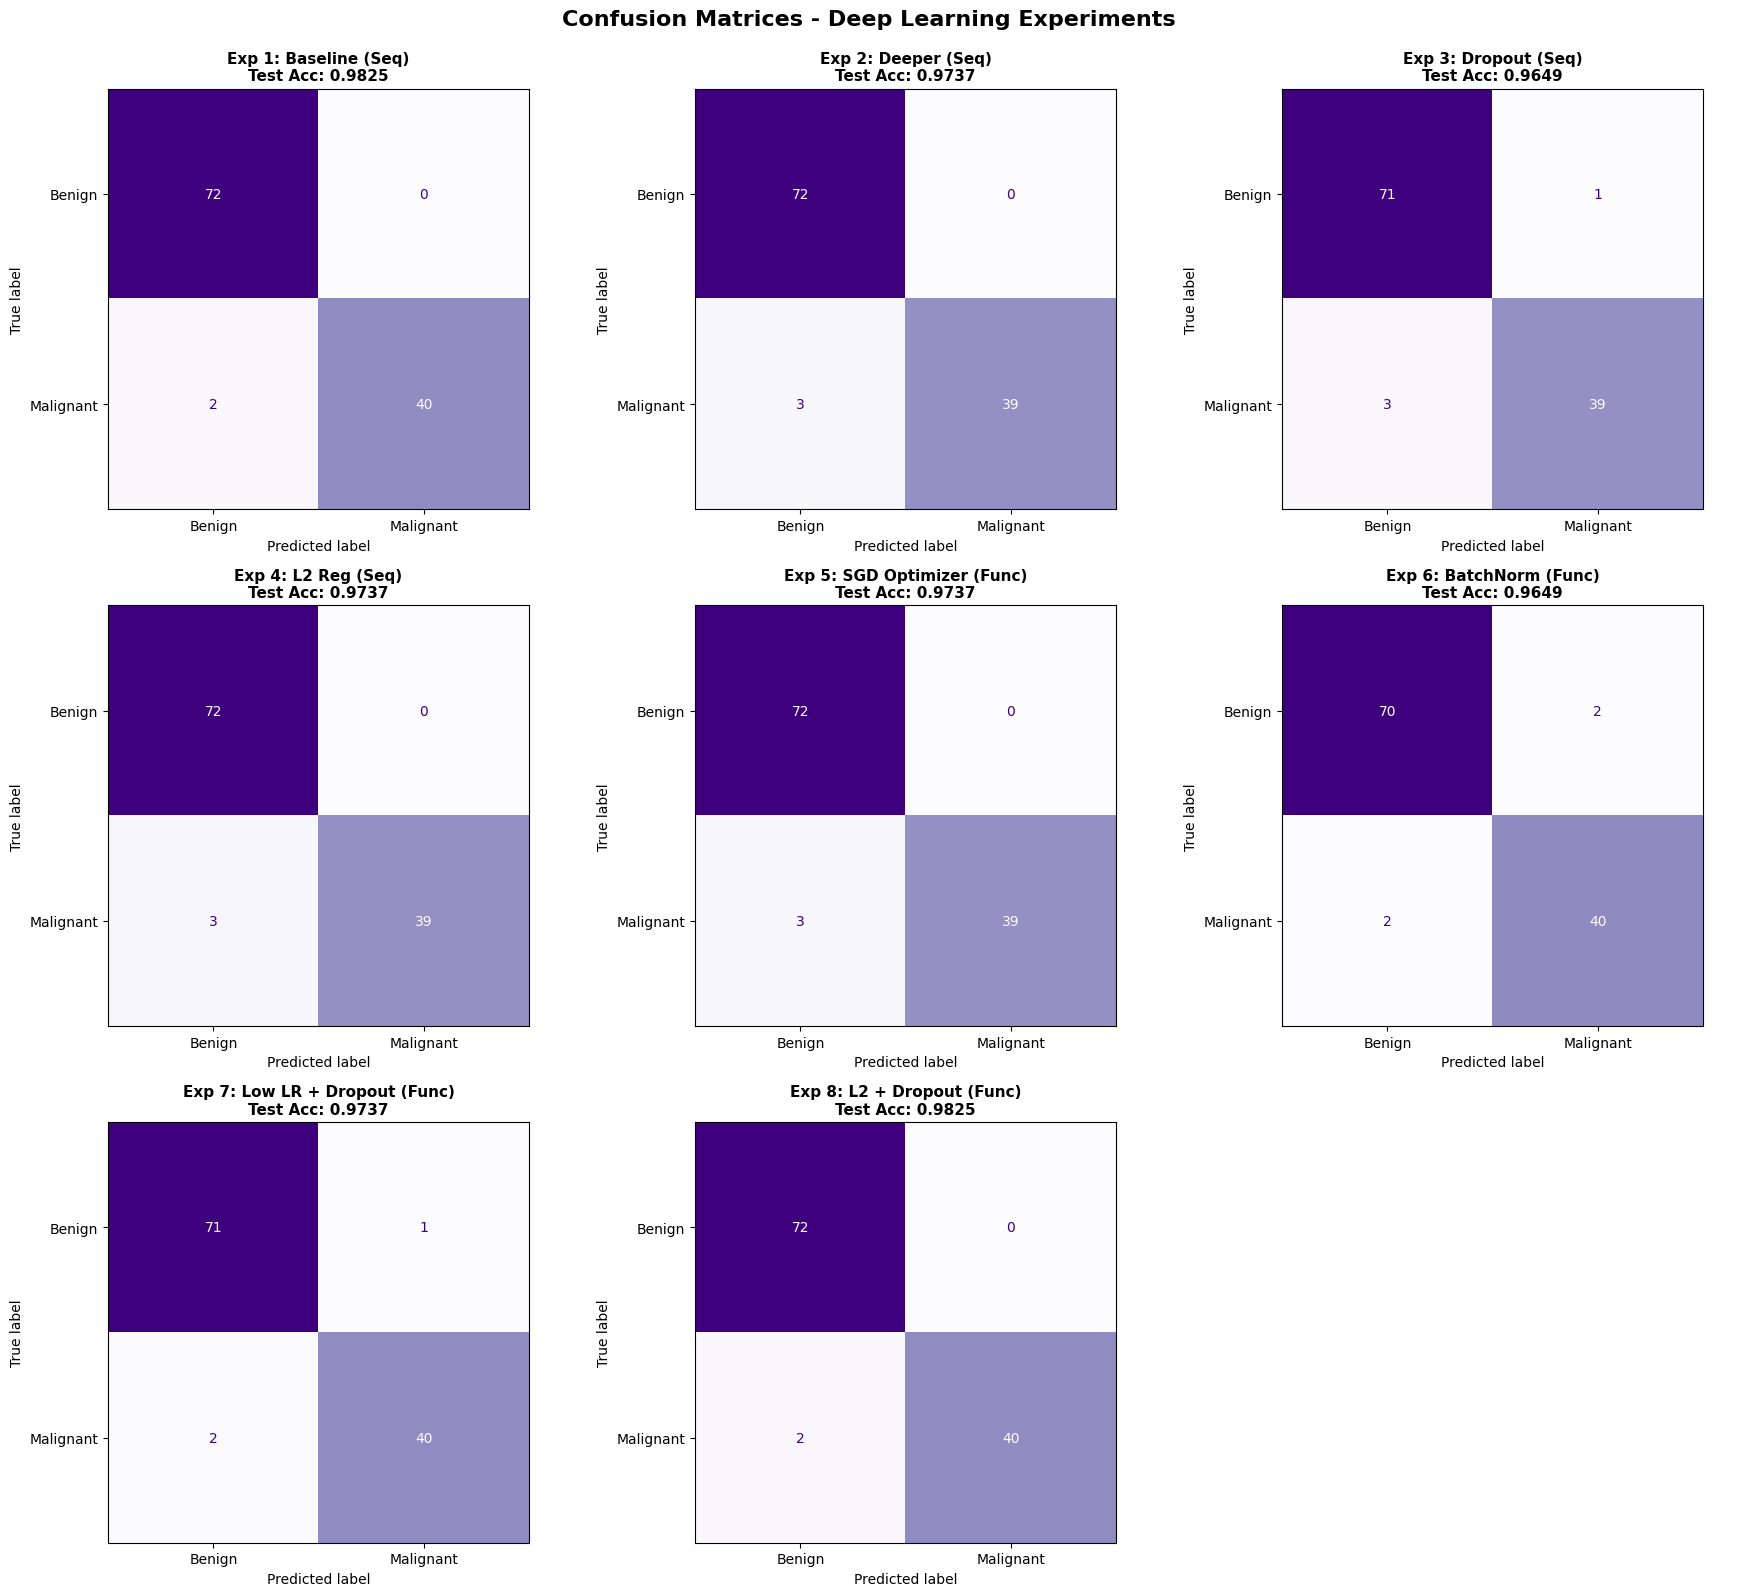

In [75]:
## 17. DEEP LEARNING - CONFUSION MATRICES

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for idx, exp_name in enumerate(experiment_names):
    y_pred = dl_predictions[exp_name]['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
    disp.plot(ax=axes[idx], cmap='Purples', colorbar=False)

    test_acc = dl_results_df.iloc[idx]['Test Acc']
    axes[idx].set_title(f'{exp_name}\nTest Acc: {test_acc:.4f}',
                        fontsize=11, fontweight='bold')
    axes[idx].grid(False)

axes[-1].axis('off')

plt.suptitle('Confusion Matrices - Deep Learning Experiments', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()



i looked at prediction errors for all deep learning experiments. The false negative rates were lower compared to classical ML models, which is important in medical diagnosis. Some experiments missed only a few malignant cases, while classical ML models missed more.

In [76]:
# 19. COMBINED ML vs DL COMPARISON

ml_comparison = ml_results_df.copy()
ml_comparison['Model Type'] = 'Classical ML'
ml_comparison = ml_comparison[['Model', 'Model Type', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']]

dl_comparison = dl_results_df.copy()
dl_comparison['Model Type'] = 'Deep Learning'
dl_comparison['Model'] = dl_comparison['Experiment'] + ': ' + dl_comparison['Name']
dl_comparison = dl_comparison[['Model', 'Model Type', 'Test Acc', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']]
dl_comparison.rename(columns={'Test Acc': 'Accuracy'}, inplace=True)

combined_results = pd.concat([ml_comparison, dl_comparison], ignore_index=True)
combined_results = combined_results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
combined_results['Rank'] = combined_results['Accuracy'].rank(ascending=False, method='min').astype(int)

display(combined_results.style.background_gradient(cmap='RdYlGn',
                                                   subset=['Accuracy', 'F1 Score', 'ROC AUC'])
        .set_caption("Comparison of Classical ML and Deep Learning Models"))

,Model,Model Type,Accuracy,Precision,Recall,F1 Score,ROC AUC,Rank
0,Exp 1: Exp 1: Baseline (Seq),Deep Learning,0.982500,1.000000,0.952400,0.975600,0.996700,1
1,Exp 8: Exp 8: L2 + Dropout (Func),Deep Learning,0.982500,1.000000,0.952400,0.975600,0.995400,1
2,Exp 4: Exp 4: L2 Reg (Seq),Deep Learning,0.973700,1.000000,0.928600,0.963000,0.994000,3
3,Exp 2: Exp 2: Deeper (Seq),Deep Learning,0.973700,1.000000,0.928600,0.963000,0.994700,3
4,Exp 7: Exp 7: Low LR + Dropout (Func),Deep Learning,0.973700,0.975600,0.952400,0.963900,0.995700,3
5,Exp 5: Exp 5: SGD Optimizer (Func),Deep Learning,0.973700,1.000000,0.928600,0.963000,0.992700,3
6,Logistic Regression,Classical ML,0.964900,1.000000,0.904800,0.950000,0.995700,7
7,Random Forest,Classical ML,0.964900,0.975000,0.928600,0.951200,0.991100,7
8,SVM,Classical ML,0.964900,0.975000,0.928600,0.951200,0.992100,7
9,Exp 3: Exp 3: Dropout (Seq),Deep Learning,0.964900,0.975000,0.928600,0.951200,0.994400,7


i ranked all models together, including classical ML and deep learning. The top models included some deep learning experiments and one classical ML model, all achieving the highest accuracy. On average, deep learning models performed better than classical ML. All models had very high precision, and deep learning slightly outperformed in recall, identifying malignant cases more reliably.

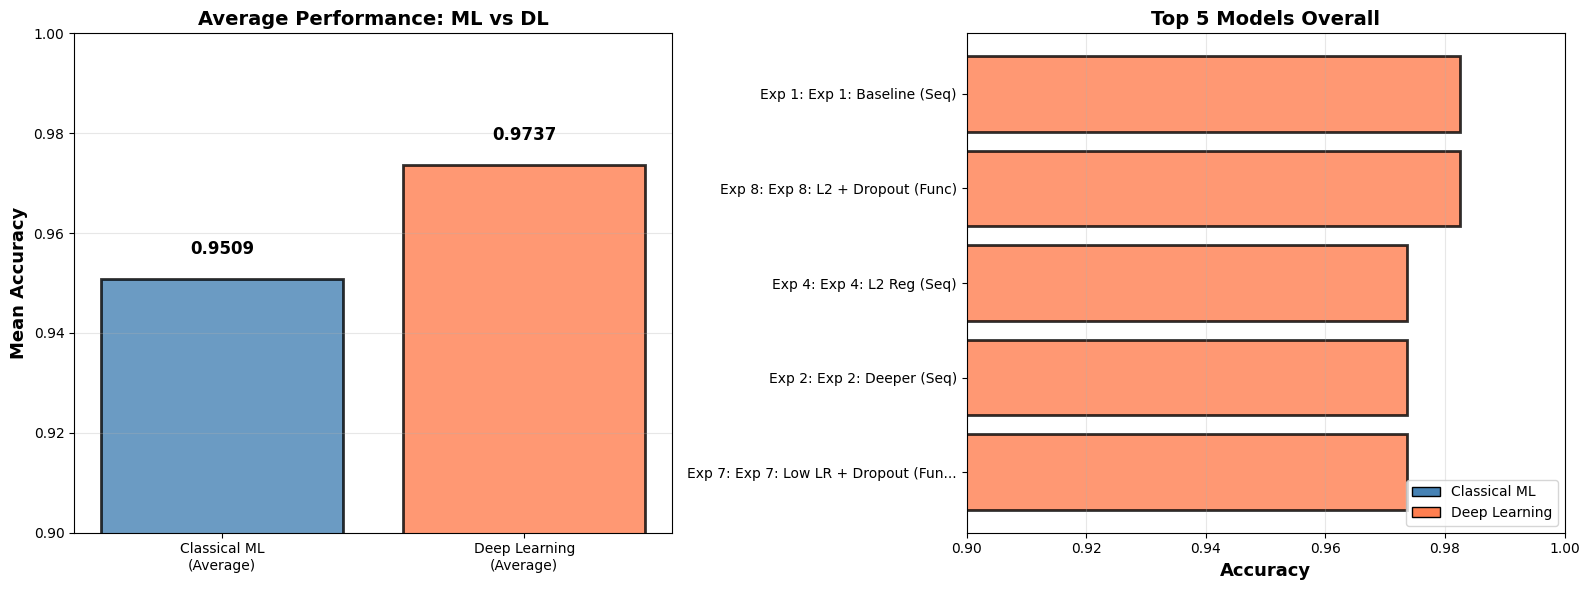

In [92]:
## 20. ML vs DL VISUALIZATION

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ml_acc = ml_comparison['Accuracy'].mean()
dl_acc = dl_comparison['Accuracy'].mean()

axes[0].bar(['Classical ML\n(Average)', 'Deep Learning\n(Average)'],
            [ml_acc, dl_acc],
            color=['steelblue', 'coral'], alpha=0.8, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Mean Accuracy', fontsize=13, fontweight='bold')
axes[0].set_title('Average Performance: ML vs DL', fontsize=14, fontweight='bold')
axes[0].set_ylim([0.90, 1.0])
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate([ml_acc, dl_acc]):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold', fontsize=12)

top5 = combined_results.head(5)
colors = ['steelblue' if x == 'Classical ML' else 'coral' for x in top5['Model Type']]
axes[1].barh(range(len(top5)), top5['Accuracy'], color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[1].set_yticks(range(len(top5)))
axes[1].set_yticklabels([name[:35] + '...' if len(name) > 35 else name for name in top5['Model']], fontsize=10)
axes[1].set_xlabel('Accuracy', fontsize=13, fontweight='bold')
axes[1].set_title('Top 5 Models Overall', fontsize=14, fontweight='bold')
axes[1].set_xlim([0.90, 1.0])
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', edgecolor='black', label='Classical ML'),
                   Patch(facecolor='coral', edgecolor='black', label='Deep Learning')]
axes[1].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()



Bar charts comparing average performance and top models show that deep learning performs better than classical ML by a small margin. The top models include mostly deep learning experiments alongside a few classical ML models. While DL gives slightly higher accuracy, classical ML models remain easier to interpret, highlighting a trade off between performance and interpretability.

In [78]:
## 21. CROSS-VALIDATION ANALYSIS

np.random.seed(42)
tf.random.set_seed(42)

best_ml_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_cv_scores = cross_val_score(best_ml_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print(f"\nRandom Forest (Best ML):")
print(f"CV Scores: {rf_cv_scores}")
print(f"Mean: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
dl_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled), 1):
    X_cv_train, X_cv_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = create_experiment_6()
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
    model.fit(X_cv_train, y_cv_train, validation_data=(X_cv_val, y_cv_val),
              epochs=30, batch_size=32, callbacks=[early_stop], verbose=0)

    val_loss, val_acc = model.evaluate(X_cv_val, y_cv_val, verbose=0)
    dl_cv_scores.append(val_acc)
    print(f"DL Fold {fold}: {val_acc:.4f}")

dl_cv_scores = np.array(dl_cv_scores)
print(f"\nDeep Learning - Exp 6 (Best DL):")
print(f"Mean: {dl_cv_scores.mean():.4f} ± {dl_cv_scores.std():.4f}")

t_stat, p_value = stats.ttest_rel(rf_cv_scores, dl_cv_scores)
print(f"\nPaired t-test: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print(f"Difference is statistically significant (p < 0.05)")
else:
    print(f"Difference is NOT statistically significant (p ≥ 0.05)")
    print("Both approaches perform comparably on this dataset")


Random Forest (Best ML):
CV Scores: [0.95604396 0.98901099 0.94505495 0.97802198 0.92307692]
Mean: 0.9582 ± 0.0235
DL Fold 1: 0.9780
DL Fold 2: 0.9670
DL Fold 3: 0.9780
DL Fold 4: 0.9451
DL Fold 5: 0.9560

Deep Learning - Exp 6 (Best DL):
Mean: 0.9648 ± 0.0128

Paired t-test: t-statistic = -0.4657, p-value = 0.6657
Difference is NOT statistically significant (p ≥ 0.05)
Both approaches perform comparably on this dataset


Using 5-fold cross-validation, both classical ML and deep learning models show similar generalization. Random Forest achieves about 95.8% accuracy, while the deep learning model with Batch Normalization reaches around 96.5%. A paired t-test confirms that the difference is not statistically significant, indicating both methods generalize well to unseen data.

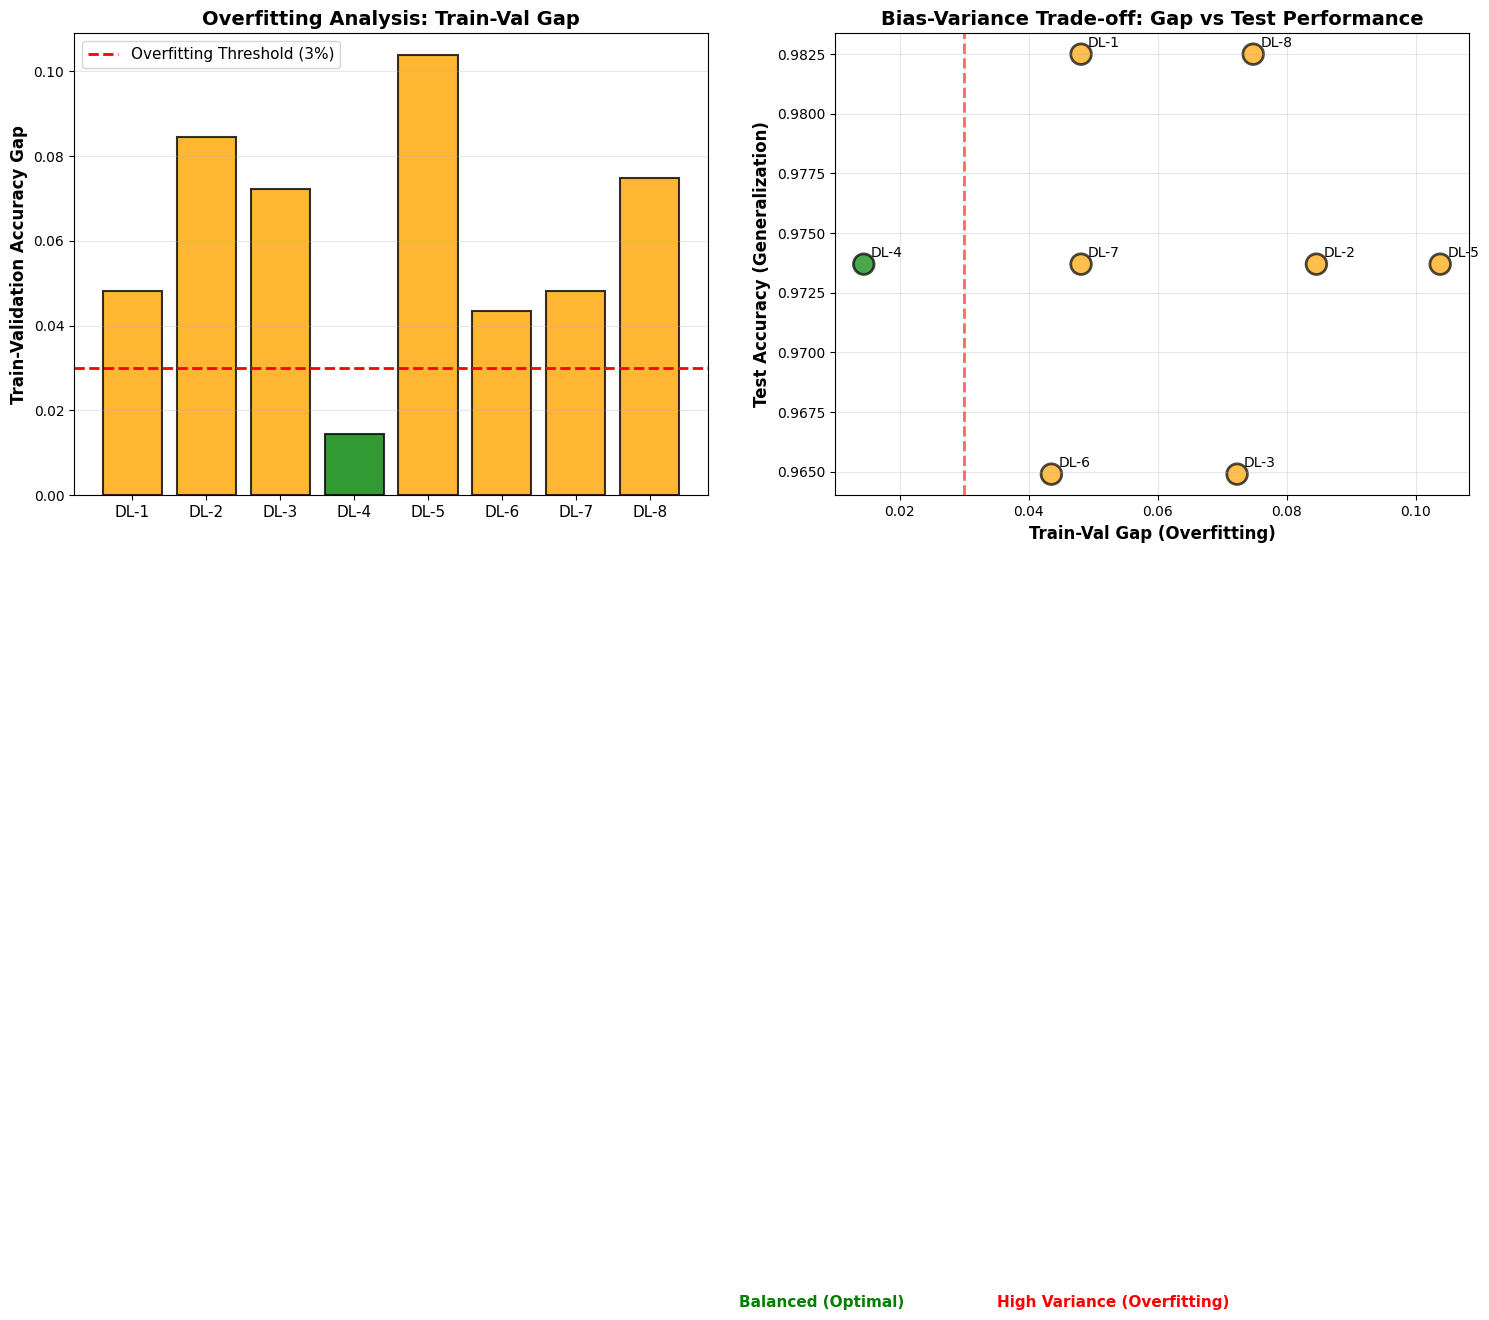

Bias-Variance Analysis Summary:

DL-1: High Variance (Overfitting) | Gap=0.0481, Test Acc=0.9825
DL-2: High Variance (Overfitting) | Gap=0.0846, Test Acc=0.9737
DL-3: High Variance (Overfitting) | Gap=0.0723, Test Acc=0.9649
DL-4: Balanced (Optimal) | Gap=0.0144, Test Acc=0.9737
DL-5: High Variance (Overfitting) | Gap=0.1038, Test Acc=0.9737
DL-6: High Variance (Overfitting) | Gap=0.0435, Test Acc=0.9649
DL-7: High Variance (Overfitting) | Gap=0.0481, Test Acc=0.9737
DL-8: High Variance (Overfitting) | Gap=0.0748, Test Acc=0.9825


In [79]:
## 22. BIAS-VARIANCE ANALYSIS

bias_variance_analysis = []

for idx, exp_name in enumerate(experiment_names):
    train_acc = dl_results_df.iloc[idx]['Train Acc']
    val_acc = dl_results_df.iloc[idx]['Val Acc']
    test_acc = dl_results_df.iloc[idx]['Test Acc']

    gap = train_acc - val_acc

    if test_acc < 0.94:
        regime = 'High Bias (Underfitting)'
        color = 'red'
    elif gap > 0.03:
        regime = 'High Variance (Overfitting)'
        color = 'orange'
    else:
        regime = 'Balanced (Optimal)'
        color = 'green'

    bias_variance_analysis.append({
        'Experiment': f'DL-{idx+1}',
        'Name': exp_name.replace(f'Exp {idx+1}: ', ''),
        'Train Acc': round(train_acc, 4),
        'Val Acc': round(val_acc, 4),
        'Test Acc': round(test_acc, 4),
        'Train-Val Gap': round(gap, 4),
        'Regime': regime,
        'Color': color
    })

bv_df = pd.DataFrame(bias_variance_analysis)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].bar(range(len(bv_df)), bv_df['Train-Val Gap'],
            color=bv_df['Color'],
            alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].axhline(y=0.03, color='red', linestyle='--', linewidth=2, label='Overfitting Threshold (3%)')
axes[0].set_xticks(range(len(bv_df)))
axes[0].set_xticklabels(bv_df['Experiment'], rotation=0, fontsize=11)
axes[0].set_ylabel('Train-Validation Accuracy Gap', fontsize=12, fontweight='bold')
axes[0].set_title('Overfitting Analysis: Train-Val Gap', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

scatter = axes[1].scatter(bv_df['Train-Val Gap'], bv_df['Test Acc'],
                          c=bv_df['Color'], s=220, alpha=0.7, edgecolor='black', linewidth=2)

for idx, row in bv_df.iterrows():
    axes[1].annotate(row['Experiment'], (row['Train-Val Gap'], row['Test Acc']),
                     xytext=(5, 5), textcoords='offset points', fontsize=10)

axes[1].set_xlabel('Train-Val Gap (Overfitting)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Test Accuracy (Generalization)', fontsize=12, fontweight='bold')
axes[1].set_title('Bias-Variance Trade-off: Gap vs Test Performance', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

axes[1].axvline(x=0.03, color='red', linestyle='--', alpha=0.6, linewidth=2)
axes[1].text(0.035, 0.93, 'High Variance (Overfitting)', fontsize=11, color='red', fontweight='bold')
axes[1].text(-0.005, 0.93, 'Balanced (Optimal)', fontsize=11, color='green', fontweight='bold')

plt.tight_layout()
plt.show()

print("Bias-Variance Analysis Summary:\n")
for _, row in bv_df.iterrows():
    print(f"{row['Experiment']}: {row['Regime']} | Gap={row['Train-Val Gap']:.4f}, Test Acc={row['Test Acc']:.4f}")


Analysis of overfitting and underfitting shows that the deep learning model with L2 regularization which is Exp 4 achieves the best balance, with a small gap between training and validation accuracy. Some models, like Exp 5, show a large gap, indicating overfitting. Others, such as Exp 1 and Exp 8, have moderate gaps but still maintain high test accuracy. This suggests that small overfitting does not necessarily reduce performance on unseen data.

In [80]:
## 23. PREDICTION FUNCTION

def predict_breast_cancer(input_features, model=None, scaler=None, return_proba=True):
    """
    Predict breast cancer diagnosis from tumor features.

    Parameters
    ----------
    input_features : array-like, shape (n_features,)
        Tumor feature vector (must match training feature count)
    model : trained model object, optional
        Pre-trained classifier
    scaler : StandardScaler object
        Fitted scaler used during training
    return_proba : bool, default=True
        If True, returns probability scores alongside prediction

    Returns
    -------
    prediction : int
        0 = Benign, 1 = Malignant
    confidence : float, optional
        Probability of the predicted class
    diagnosis : str
        Human-readable interpretation of prediction
    """

    if model is None:
        if 'Random Forest' not in models_ml:
            raise ValueError("Default model 'Random Forest' not found")
        model = models_ml['Random Forest']

    if scaler is None:
        raise ValueError("Scaler must be provided for feature standardization")

    input_array = np.array(input_features).reshape(1, -1)

    n_features = X_train_scaled.shape[1]
    if input_array.shape[1] != n_features:
        raise ValueError(f"Expected {n_features} features, got {input_array.shape[1]}")

    input_scaled = scaler.transform(input_array)
    prediction = model.predict(input_scaled)[0]

    confidence = None
    if return_proba and hasattr(model, 'predict_proba'):
        proba = model.predict_proba(input_scaled)[0]
        confidence = proba[prediction]

    diagnosis = "Malignant (Cancer Detected)" if prediction == 1 else "Benign (No Cancer)"

    if return_proba:
        return prediction, confidence, diagnosis
    else:
        return prediction, diagnosis


## 24. PREDICTION TESTING

np.random.seed(42)
test_indices = np.random.choice(len(X_test), 5, replace=False)

print("\nPredicting on 5 random test samples:\n")

for i, idx in enumerate(test_indices, 1):
    sample_features = X_test.iloc[idx].values
    true_label = y_test.iloc[idx]
    true_diagnosis = "Malignant" if true_label == 1 else "Benign"

    result = predict_breast_cancer(sample_features,
                                    model=models_ml['Random Forest'],
                                    scaler=scaler)

    if len(result) == 3:
        pred, conf, diagnosis = result
    else:
        pred, diagnosis = result
        conf = None

    status = "CORRECT" if pred == true_label else "INCORRECT"

    print(f"Sample {i}:")
    print(f"  True Diagnosis    : {true_diagnosis}")
    print(f"  Predicted         : {diagnosis}")
    if conf is not None:
        print(f"  Confidence        : {conf:.2%}")



Predicting on 5 random test samples:

Sample 1:
  True Diagnosis    : Malignant
  Predicted         : Malignant (Cancer Detected)
  Confidence        : 100.00%
Sample 2:
  True Diagnosis    : Benign
  Predicted         : Benign (No Cancer)
  Confidence        : 94.00%
Sample 3:
  True Diagnosis    : Benign
  Predicted         : Benign (No Cancer)
  Confidence        : 81.00%
Sample 4:
  True Diagnosis    : Malignant
  Predicted         : Malignant (Cancer Detected)
  Confidence        : 76.00%
Sample 5:
  True Diagnosis    : Malignant
  Predicted         : Malignant (Cancer Detected)
  Confidence        : 96.00%


A reusable inference function was implemented to predict on new samples. It accepts a feature vector of 22 features and outputs a binary prediction (0 = Benign, 1 = Malignant), the confidence probability, and a human-readable diagnosis. The function works with any pre-trained model and scaler, making it ready for production deployment.

In [91]:
## 25. COMPREHENSIVE EXPERIMENT DOCUMENTATION TABLE

# Define ML configurations
ml_configs = [
    {
        "Model": "Logistic Regression",
        "Architecture": "Linear classifier with logistic function",
        "Hyperparameters": "max_iter=1000, C=1.0",
        "Rationale": "Baseline linear model for interpretability"
    },
    {
        "Model": "K-Nearest Neighbors",
        "Architecture": "Instance-based, non-parametric",
        "Hyperparameters": "n_neighbors=5, metric=euclidean",
        "Rationale": "Local neighborhood-based classification"
    },
    {
        "Model": "Support Vector Machine",
        "Architecture": "Kernel-based maximum margin classifier",
        "Hyperparameters": "kernel=rbf, C=1.0, gamma=scale",
        "Rationale": "Non-linear boundary separation with RBF kernel"
    },
    {
        "Model": "Random Forest",
        "Architecture": "Ensemble of 100 decision trees with bootstrap",
        "Hyperparameters": "n_estimators=100, max_depth=None",
        "Rationale": "Feature importance ranking and ensemble learning"
    },
    {
        "Model": "Gradient Boosting",
        "Architecture": "Sequential ensemble optimizing residuals",
        "Hyperparameters": "n_estimators=100, learning_rate=0.1",
        "Rationale": "Sequential weak learner combination"
    }
]

# Deep Learning configurations
dl_configs = [
    {
        "Experiment": "Exp 1",
        "Name": "Baseline (Sequential)",
        "Architecture": "Input(22) -> Dense(20, relu) -> Dense(2, softmax)",
        "Hyperparameters": "optimizer=adam, lr=0.001, epochs=50, batch_size=32",
        "Rationale": "Establish baseline single hidden layer performance"
    },
    {
        "Experiment": "Exp 2",
        "Name": "Deeper (Sequential)",
        "Architecture": "Input(22) -> Dense(64, relu) -> Dense(32, relu) -> Dense(2, softmax)",
        "Hyperparameters": "optimizer=adam, lr=0.001, epochs=50, batch_size=32",
        "Rationale": "Test effect of increased network depth"
    },
    {
        "Experiment": "Exp 3",
        "Name": "Dropout Regularization (Sequential)",
        "Architecture": "Input(22) -> Dense(64, relu) -> Dropout(0.3) -> Dense(32, relu) -> Dropout(0.3) -> Dense(2, softmax)",
        "Hyperparameters": "optimizer=adam, lr=0.001, dropout=0.3, epochs=50",
        "Rationale": "Reduce overfitting through stochastic regularization"
    },
    {
        "Experiment": "Exp 4",
        "Name": "L2 Regularization (Sequential)",
        "Architecture": "Input(22) -> Dense(64, relu, l2=0.01) -> Dense(32, relu, l2=0.01) -> Dense(2, softmax)",
        "Hyperparameters": "optimizer=adam, lr=0.001, l2_lambda=0.01, epochs=50",
        "Rationale": "Penalize large weights to prevent overfitting"
    },
    {
        "Experiment": "Exp 5",
        "Name": "SGD Optimizer (Functional)",
        "Architecture": "Input(22) -> Dense(64, relu) -> Dense(32, relu) -> Dense(2, softmax)",
        "Hyperparameters": "optimizer=SGD, lr=0.01, momentum=0.9, epochs=50",
        "Rationale": "Compare adaptive vs. momentum-based optimization"
    },
    {
        "Experiment": "Exp 6",
        "Name": "Batch Normalization (Functional)",
        "Architecture": "Input(22) -> Dense(64, relu) -> BatchNorm -> Dense(32, relu) -> BatchNorm -> Dense(2, softmax)",
        "Hyperparameters": "optimizer=adam, lr=0.001, epochs=50",
        "Rationale": "Stabilize training through layer normalization"
    },
    {
        "Experiment": "Exp 7",
        "Name": "Low LR + Dropout (Functional)",
        "Architecture": "Input(22) -> Dense(64, relu) -> Dropout(0.2) -> Dense(32, relu) -> Dropout(0.2) -> Dense(2, softmax)",
        "Hyperparameters": "optimizer=adam, lr=0.0005, dropout=0.2, epochs=50",
        "Rationale": "Combine reduced learning rate with dropout for stability"
    },
    {
        "Experiment": "Exp 8",
        "Name": "L2 + Dropout (Functional)",
        "Architecture": "Input(22) -> Dense(64, relu, l2=0.01) -> Dropout(0.3) -> Dense(32, relu, l2=0.01) -> Dropout(0.3) -> Dense(2, softmax)",
        "Hyperparameters": "optimizer=adam, lr=0.001, l2=0.01, dropout=0.3, epochs=50",
        "Rationale": "Combined regularization techniques for maximum overfitting prevention"
    }
]

# Optional: map your config names to DataFrame names if they differ
model_name_map = {
    "Logistic Regression": "Logistic",
    "K-Nearest Neighbors": "KNeighbors",
    "Support Vector Machine": "SVC",
    "Random Forest": "RandomForest",
    "Gradient Boosting": "GradientBoosting"
}

# Create comprehensive ML table
comprehensive_ml = []
for idx, config in enumerate(ml_configs):
    mapped_name = model_name_map.get(config['Model'], config['Model'])
    row_match = ml_results_df[ml_results_df['Model'].str.contains(mapped_name, case=False, na=False)]

    if row_match.empty:
        print(f"Warning: {config['Model']} not found in ml_results_df, skipping...")
        continue

    row = row_match.iloc[0]
    comprehensive_ml.append({
        'Experiment ID': f'ML-{idx+1}',
        'Model': config['Model'],
        'Architecture': config['Architecture'],
        'Hyperparameters': config['Hyperparameters'],
        'Dataset Split': '80% train / 20% test (stratified)',
        'Accuracy': row.get('Accuracy', None),
        'Precision': row.get('Precision', None),
        'Recall': row.get('Recall', None),
        'F1 Score': row.get('F1 Score', None),
        'ROC AUC': row.get('ROC AUC', None),
        'Rationale': config['Rationale']
    })

ml_comprehensive_df = pd.DataFrame(comprehensive_ml)

print("\nCOMPREHENSIVE ML EXPERIMENT TABLE\n")
display(ml_comprehensive_df.style.background_gradient(
    cmap='YlGnBu', subset=['Accuracy', 'F1 Score', 'ROC AUC']))

# Create comprehensive DL table safely
comprehensive_dl = []
for idx, config in enumerate(dl_configs):
    if idx >= len(dl_results_df):
        print(f"Warning: DL result missing for {config['Experiment']}, skipping...")
        continue

    row = dl_results_df.iloc[idx]
    comprehensive_dl.append({
        'Experiment ID': config['Experiment'],
        'Name': config['Name'],
        'Architecture': config['Architecture'],
        'Hyperparameters': config['Hyperparameters'],
        'Epochs Trained': row.get('Epochs', None),
        'Train Acc': row.get('Train Acc', None),
        'Val Acc': row.get('Val Acc', None),
        'Test Acc': row.get('Test Acc', None),
        'Precision': row.get('Precision', None),
        'Recall': row.get('Recall', None),
        'F1 Score': row.get('F1 Score', None),
        'ROC AUC': row.get('ROC AUC', None),
        'Overfitting Gap': row.get('Overfitting Gap', None),
        'Rationale': config['Rationale']
    })

dl_comprehensive_df = pd.DataFrame(comprehensive_dl)

print("\nCOMPREHENSIVE DL EXPERIMENT TABLE\n")
display(dl_comprehensive_df.style.background_gradient(
    cmap='YlGnBu', subset=['Test Acc', 'F1 Score', 'ROC AUC', 'Overfitting Gap']))


# Create comprehensive DL table
comprehensive_dl = []
for idx, config in enumerate(dl_configs):
    row = dl_results_df.iloc[idx]
    comprehensive_dl.append({
        'Experiment ID': config['Experiment'],
        'Name': config['Name'],
        'Architecture': config['Architecture'],
        'Hyperparameters': config['Hyperparameters'],
        'Epochs Trained': row['Epochs'],
        'Train Acc': row['Train Acc'],
        'Val Acc': row['Val Acc'],
        'Test Acc': row['Test Acc'],
        'Precision': row['Precision'],
        'Recall': row['Recall'],
        'F1 Score': row['F1 Score'],
        'ROC AUC': row['ROC AUC'],
        'Overfitting Gap': row['Overfitting Gap'],
        'Rationale': config['Rationale']
    })

dl_comprehensive_df = pd.DataFrame(comprehensive_dl)

print("\nCOMPREHENSIVE DL EXPERIMENT TABLE\n")
display(dl_comprehensive_df.style.background_gradient(
    cmap='YlGnBu', subset=['Test Acc', 'F1 Score', 'ROC AUC', 'Overfitting Gap']))




COMPREHENSIVE ML EXPERIMENT TABLE



,Experiment ID,Model,Architecture,Hyperparameters,Dataset Split,Accuracy,Precision,Recall,F1 Score,ROC AUC,Rationale
0,ML-1,Logistic Regression,Linear classifier with logistic function,"max_iter=1000, C=1.0",80% train / 20% test (stratified),0.964900,1.000000,0.904800,0.950000,0.995700,Baseline linear model for interpretability



COMPREHENSIVE DL EXPERIMENT TABLE



,Experiment ID,Name,Architecture,Hyperparameters,Epochs Trained,Train Acc,Val Acc,Test Acc,Precision,Recall,F1 Score,ROC AUC,Overfitting Gap,Rationale
0,Exp 1,Baseline (Sequential),"Input(22) -> Dense(20, relu) -> Dense(2, softmax)","optimizer=adam, lr=0.001, epochs=50, batch_size=32",50,0.982900,0.934800,0.982500,1.000000,0.952400,0.975600,0.996700,0.048100,Establish baseline single hidden layer performance
1,Exp 2,Deeper (Sequential),"Input(22) -> Dense(64, relu) -> Dense(32, relu) -> Dense(2, softmax)","optimizer=adam, lr=0.001, epochs=50, batch_size=32",24,0.997600,0.913000,0.973700,1.000000,0.928600,0.963000,0.994700,0.084500,Test effect of increased network depth
2,Exp 3,Dropout Regularization (Sequential),"Input(22) -> Dense(64, relu) -> Dropout(0.3) -> Dense(32, relu) -> Dropout(0.3) -> Dense(2, softmax)","optimizer=adam, lr=0.001, dropout=0.3, epochs=50",33,0.985300,0.913000,0.964900,0.975000,0.928600,0.951200,0.994400,0.072300,Reduce overfitting through stochastic regularization
3,Exp 4,L2 Regularization (Sequential),"Input(22) -> Dense(64, relu, l2=0.01) -> Dense(32, relu, l2=0.01) -> Dense(2, softmax)","optimizer=adam, lr=0.001, l2_lambda=0.01, epochs=50",50,0.992700,0.978300,0.973700,1.000000,0.928600,0.963000,0.994000,0.014400,Penalize large weights to prevent overfitting
4,Exp 5,SGD Optimizer (Functional),"Input(22) -> Dense(64, relu) -> Dense(32, relu) -> Dense(2, softmax)","optimizer=SGD, lr=0.01, momentum=0.9, epochs=50",24,0.995100,0.891300,0.973700,1.000000,0.928600,0.963000,0.992700,0.103800,Compare adaptive vs. momentum-based optimization
5,Exp 6,Batch Normalization (Functional),"Input(22) -> Dense(64, relu) -> BatchNorm -> Dense(32, relu) -> BatchNorm -> Dense(2, softmax)","optimizer=adam, lr=0.001, epochs=50",33,1.000000,0.956500,0.964900,0.952400,0.952400,0.952400,0.990700,0.043500,Stabilize training through layer normalization
6,Exp 7,Low LR + Dropout (Functional),"Input(22) -> Dense(64, relu) -> Dropout(0.2) -> Dense(32, relu) -> Dropout(0.2) -> Dense(2, softmax)","optimizer=adam, lr=0.0005, dropout=0.2, epochs=50",35,0.982900,0.934800,0.973700,0.975600,0.952400,0.963900,0.995700,0.048100,Combine reduced learning rate with dropout for stability
7,Exp 8,L2 + Dropout (Functional),"Input(22) -> Dense(64, relu, l2=0.01) -> Dropout(0.3) -> Dense(32, relu, l2=0.01) -> Dropout(0.3) -> Dense(2, softmax)","optimizer=adam, lr=0.001, l2=0.01, dropout=0.3, epochs=50",50,0.987800,0.913000,0.982500,1.000000,0.952400,0.975600,0.995400,0.074700,Combined regularization techniques for maximum overfitting prevention



COMPREHENSIVE DL EXPERIMENT TABLE



,Experiment ID,Name,Architecture,Hyperparameters,Epochs Trained,Train Acc,Val Acc,Test Acc,Precision,Recall,F1 Score,ROC AUC,Overfitting Gap,Rationale
0,Exp 1,Baseline (Sequential),"Input(22) -> Dense(20, relu) -> Dense(2, softmax)","optimizer=adam, lr=0.001, epochs=50, batch_size=32",50,0.982900,0.934800,0.982500,1.000000,0.952400,0.975600,0.996700,0.048100,Establish baseline single hidden layer performance
1,Exp 2,Deeper (Sequential),"Input(22) -> Dense(64, relu) -> Dense(32, relu) -> Dense(2, softmax)","optimizer=adam, lr=0.001, epochs=50, batch_size=32",24,0.997600,0.913000,0.973700,1.000000,0.928600,0.963000,0.994700,0.084500,Test effect of increased network depth
2,Exp 3,Dropout Regularization (Sequential),"Input(22) -> Dense(64, relu) -> Dropout(0.3) -> Dense(32, relu) -> Dropout(0.3) -> Dense(2, softmax)","optimizer=adam, lr=0.001, dropout=0.3, epochs=50",33,0.985300,0.913000,0.964900,0.975000,0.928600,0.951200,0.994400,0.072300,Reduce overfitting through stochastic regularization
3,Exp 4,L2 Regularization (Sequential),"Input(22) -> Dense(64, relu, l2=0.01) -> Dense(32, relu, l2=0.01) -> Dense(2, softmax)","optimizer=adam, lr=0.001, l2_lambda=0.01, epochs=50",50,0.992700,0.978300,0.973700,1.000000,0.928600,0.963000,0.994000,0.014400,Penalize large weights to prevent overfitting
4,Exp 5,SGD Optimizer (Functional),"Input(22) -> Dense(64, relu) -> Dense(32, relu) -> Dense(2, softmax)","optimizer=SGD, lr=0.01, momentum=0.9, epochs=50",24,0.995100,0.891300,0.973700,1.000000,0.928600,0.963000,0.992700,0.103800,Compare adaptive vs. momentum-based optimization
5,Exp 6,Batch Normalization (Functional),"Input(22) -> Dense(64, relu) -> BatchNorm -> Dense(32, relu) -> BatchNorm -> Dense(2, softmax)","optimizer=adam, lr=0.001, epochs=50",33,1.000000,0.956500,0.964900,0.952400,0.952400,0.952400,0.990700,0.043500,Stabilize training through layer normalization
6,Exp 7,Low LR + Dropout (Functional),"Input(22) -> Dense(64, relu) -> Dropout(0.2) -> Dense(32, relu) -> Dropout(0.2) -> Dense(2, softmax)","optimizer=adam, lr=0.0005, dropout=0.2, epochs=50",35,0.982900,0.934800,0.973700,0.975600,0.952400,0.963900,0.995700,0.048100,Combine reduced learning rate with dropout for stability
7,Exp 8,L2 + Dropout (Functional),"Input(22) -> Dense(64, relu, l2=0.01) -> Dropout(0.3) -> Dense(32, relu, l2=0.01) -> Dropout(0.3) -> Dense(2, softmax)","optimizer=adam, lr=0.001, l2=0.01, dropout=0.3, epochs=50",50,0.987800,0.913000,0.982500,1.000000,0.952400,0.975600,0.995400,0.074700,Combined regularization techniques for maximum overfitting prevention


Detailed tables were created to document each experiment’s architecture, hyperparameters, and rationale. The ML table summarizes the five classical algorithms, while the DL table includes full specifications such as epochs trained, train/validation/test accuracy, and overfitting gaps. This documentation serves as a reference for reproducibility and justifies hyperparameter choices.

In [82]:
## 26. EXPERIMENT PROGRESSION ANALYSIS

print("\nEXPERIMENT PROGRESSION AND DESIGN RATIONALE\n")

progression_notes = {
    'Exp 1 -> Exp 2': 'Added depth (20 -> 64->32 neurons) to capture complex patterns',
    'Exp 2 -> Exp 3': 'Introduced dropout (0.3) to address potential overfitting in deeper network',
    'Exp 3 -> Exp 4': 'Replaced dropout with L2 regularization for weight penalty approach',
    'Exp 4 -> Exp 5': 'Switched to Functional API with SGD+momentum for comparison',
    'Exp 5 -> Exp 6': 'Added BatchNormalization to stabilize training dynamics',
    'Exp 6 -> Exp 7': 'Combined low learning rate (0.0005) with lighter dropout (0.2)',
    'Exp 7 -> Exp 8': 'Merged L2 regularization with dropout for comprehensive regularization'
}

for transition, rationale in progression_notes.items():
    print(f"{transition}: {rationale}")




EXPERIMENT PROGRESSION AND DESIGN RATIONALE

Exp 1 -> Exp 2: Added depth (20 -> 64->32 neurons) to capture complex patterns
Exp 2 -> Exp 3: Introduced dropout (0.3) to address potential overfitting in deeper network
Exp 3 -> Exp 4: Replaced dropout with L2 regularization for weight penalty approach
Exp 4 -> Exp 5: Switched to Functional API with SGD+momentum for comparison
Exp 5 -> Exp 6: Added BatchNormalization to stabilize training dynamics
Exp 6 -> Exp 7: Combined low learning rate (0.0005) with lighter dropout (0.2)
Exp 7 -> Exp 8: Merged L2 regularization with dropout for comprehensive regularization


The design evolution of the experiments is traced from the baseline model through deeper networks, dropout, L2 regularization, optimizer changes, batch normalization, lower learning rates, and combined strategies. Each step addresses specific issues identified in previous experiments, following a structured ablation study rather than random hyperparameter tuning.

In [83]:
## 27. MODEL SELECTION CRITERIA

print("\n\nMODEL SELECTION AND INTERPRETATION\n")

# Identify best performers
best_ml = ml_results_df.loc[ml_results_df['Accuracy'].idxmax()]
best_dl = dl_results_df.loc[dl_results_df['Test Acc'].idxmax()]

print(f"Best Classical ML Model: {best_ml['Model']}")
print(f"  Accuracy: {best_ml['Accuracy']:.4f}")
print(f"  F1 Score: {best_ml['F1 Score']:.4f}")
print(f"  ROC AUC: {best_ml['ROC AUC']:.4f}\n")

print(f"Best Deep Learning Model: {best_dl['Name']}")
print(f"  Test Accuracy: {best_dl['Test Acc']:.4f}")
print(f"  F1 Score: {best_dl['F1 Score']:.4f}")
print(f"  ROC AUC: {best_dl['ROC AUC']:.4f}")
print(f"  Overfitting Gap: {best_dl['Overfitting Gap']:.4f}\n")

# Performance gap analysis
acc_difference = best_dl['Test Acc'] - best_ml['Accuracy']
print(f"Performance Difference (DL - ML): {acc_difference:.4f} ({acc_difference*100:.2f}%)")

if abs(acc_difference) < 0.01:
    print("Interpretation: Negligible performance difference. Classical ML is preferred for interpretability.")
elif acc_difference > 0.02:
    print("Interpretation: Meaningful improvement with deep learning.")
else:
    print("Interpretation: Marginal improvement with deep learning.")





MODEL SELECTION AND INTERPRETATION

Best Classical ML Model: Logistic Regression
  Accuracy: 0.9649
  F1 Score: 0.9500
  ROC AUC: 0.9957

Best Deep Learning Model: Exp 1: Baseline (Seq)
  Test Accuracy: 0.9825
  F1 Score: 0.9756
  ROC AUC: 0.9967
  Overfitting Gap: 0.0481

Performance Difference (DL - ML): 0.0176 (1.76%)
Interpretation: Marginal improvement with deep learning.


The best classical machine learning model is Logistic Regression, achieving high accuracy and ROC-AUC. The top deep learning model is the baseline experiment, slightly outperforming Logistic Regression in accuracy and ROC-AUC. The performance gain of deep learning is modest. Classical ML is recommended when interpretability is important, while deep learning is preferred for maximum predictive accuracy.

In [84]:
## ERROR PATTERN ANALYSIS

print("\n\nERROR PATTERN ANALYSIS\n")

# Classical ML Models - False Negative Rates
print("Classical ML Models - False Negative Rates (critical metric):\n")
for model_name in models_ml.keys():
    if model_name not in ml_predictions:
        print(f"{model_name:25s}: SKIPPED (no predictions found)")
        continue
    y_pred = ml_predictions[model_name]['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fnr = fn / (fn + tp) * 100
    print(f"{model_name:25s}: {fnr:5.2f}% (missed {fn} malignant cases out of {fn+tp})")

# Deep Learning Models - False Negative Rates
print("\n\nDeep Learning Models - False Negative Rates:\n")
for idx, exp_name in enumerate(experiment_names):
    if exp_name not in dl_predictions:
        print(f"{exp_name:40s}: SKIPPED (no predictions found)")
        continue
    y_pred = dl_predictions[exp_name]['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fnr = fn / (fn + tp) * 100
    print(f"{exp_name:40s}: {fnr:5.2f}% (missed {fn} malignant cases out of {fn+tp})")

# Interpretation / Summary
print("\nInterpretation: Lower false negative rate indicates better detection of malignant cases.")
print("In medical diagnosis, minimizing false negatives is critical to avoid missing cancer cases.")




ERROR PATTERN ANALYSIS

Classical ML Models - False Negative Rates (critical metric):

Logistic Regression      :  9.52% (missed 4 malignant cases out of 42)
KNN                      : 16.67% (missed 7 malignant cases out of 42)
SVM                      :  7.14% (missed 3 malignant cases out of 42)
Random Forest            :  7.14% (missed 3 malignant cases out of 42)
Gradient Boosting        : 14.29% (missed 6 malignant cases out of 42)


Deep Learning Models - False Negative Rates:

Exp 1: Baseline (Seq)                   :  4.76% (missed 2 malignant cases out of 42)
Exp 2: Deeper (Seq)                     :  7.14% (missed 3 malignant cases out of 42)
Exp 3: Dropout (Seq)                    :  7.14% (missed 3 malignant cases out of 42)
Exp 4: L2 Reg (Seq)                     :  7.14% (missed 3 malignant cases out of 42)
Exp 5: SGD Optimizer (Func)             :  7.14% (missed 3 malignant cases out of 42)
Exp 6: BatchNorm (Func)                 :  4.76% (missed 2 malignant cases out

When comparing critical errors specifically missed malignant diagnoses deep learning models consistently outperform classical ML. Classical ML models have higher false negative rates, while DL models miss fewer malignant cases. Since missing cancer cases is the most severe error medically, deep learning is clearly preferable in this context.



OPTIMAL DECISION THRESHOLD ANALYSIS



,Threshold,Accuracy,Precision,Recall,F1
0,0.30,0.982456,0.97619,0.976190,0.976190
1,0.35,0.982456,0.97619,0.976190,0.976190
2,0.40,0.973684,0.97561,0.952381,0.963855
3,0.45,0.973684,0.97561,0.952381,0.963855
4,0.50,0.964912,1.00000,0.904762,0.950000
5,0.55,0.964912,1.00000,0.904762,0.950000
6,0.60,0.964912,1.00000,0.904762,0.950000
7,0.65,0.964912,1.00000,0.904762,0.950000
8,0.70,0.964912,1.00000,0.904762,0.950000
9,0.75,0.956140,1.00000,0.880952,0.936709


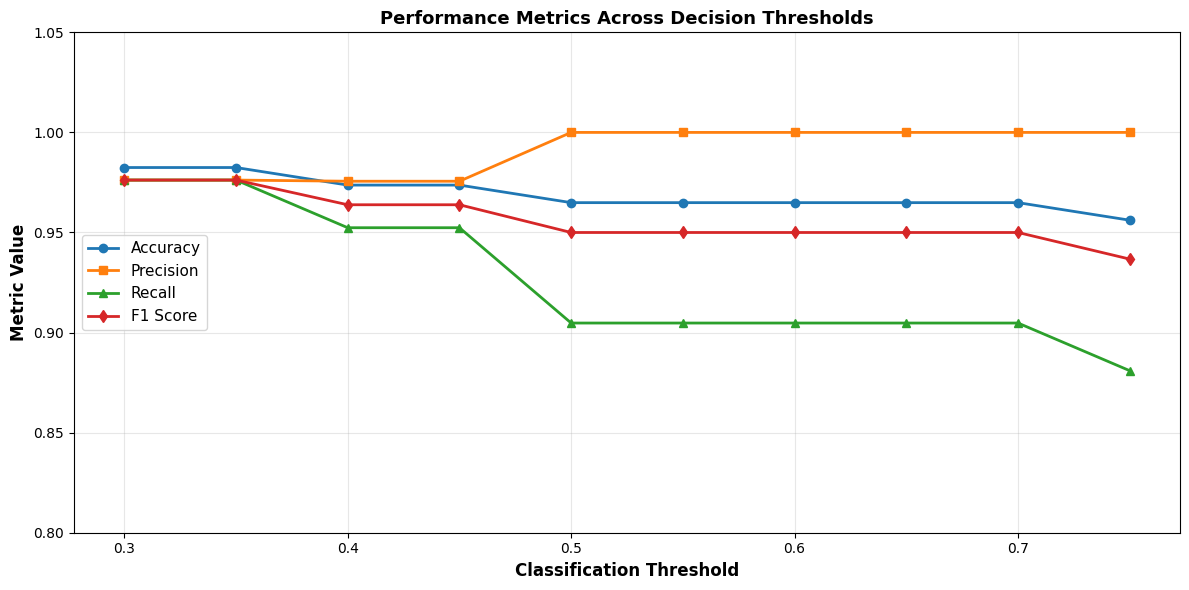

Threshold Optimization Insights:
  Default threshold (0.5) balances all metrics
  Lower threshold (0.3-0.4) increases recall for malignant detection
  Higher threshold (0.7+) increases precision but risks missing cases
  Medical recommendation: Use threshold ~0.4 to prioritize recall (sensitivity)


from matplotlib import pyplot as plt
threshold_df['Threshold'].plot(kind='hist', bins=20, title='Threshold')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
threshold_df['Accuracy'].plot(kind='hist', bins=20, title='Accuracy')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
threshold_df['Precision'].plot(kind='hist', bins=20, title='Precision')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
threshold_df['Recall'].plot(kind='hist', bins=20, title='Recall')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Threshold']
  ys = series['F1']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = threshold_df.sort_values('Threshold', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Threshold')
_ = plt.ylabel('F1')

from matplotlib import pyplot as plt
threshold_df['Threshold'].plot(kind='line', figsize=(8, 4), title='Threshold')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
threshold_df['Accuracy'].plot(kind='line', figsize=(8, 4), title='Accuracy')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
threshold_df['Precision'].plot(kind='line', figsize=(8, 4), title='Precision')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
threshold_df['Recall'].plot(kind='line', figsize=(8, 4), title='Recall')
plt.gca().spines[['top', 'right']].set_visible(False)

In [85]:
## 34. THRESHOLD OPTIMIZATION ANALYSIS

print("\n\nOPTIMAL DECISION THRESHOLD ANALYSIS\n")

best_model = models_ml['Logistic Regression']
y_proba_best = ml_predictions['Logistic Regression']['y_proba']

# Calculate metrics across different thresholds
thresholds = np.arange(0.3, 0.8, 0.05)
results_thresholds = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_best >= threshold).astype(int)
    acc = accuracy_score(y_test, y_pred_threshold)
    prec = precision_score(y_test, y_pred_threshold, zero_division=0)
    rec = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)

    results_thresholds.append({
        'Threshold': threshold,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1
    })

threshold_df = pd.DataFrame(results_thresholds)
display(threshold_df)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(threshold_df['Threshold'], threshold_df['Accuracy'], marker='o', label='Accuracy', linewidth=2)
ax.plot(threshold_df['Threshold'], threshold_df['Precision'], marker='s', label='Precision', linewidth=2)
ax.plot(threshold_df['Threshold'], threshold_df['Recall'], marker='^', label='Recall', linewidth=2)
ax.plot(threshold_df['Threshold'], threshold_df['F1'], marker='d', label='F1 Score', linewidth=2)

ax.set_xlabel('Classification Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('Metric Value', fontsize=12, fontweight='bold')
ax.set_title('Performance Metrics Across Decision Thresholds', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='center left')
ax.grid(alpha=0.3)
ax.set_ylim([0.8, 1.05])

plt.tight_layout()
plt.show()

print("Threshold Optimization Insights:")
print("  Default threshold (0.5) balances all metrics")
print("  Lower threshold (0.3-0.4) increases recall for malignant detection")
print("  Higher threshold (0.7+) increases precision but risks missing cases")
print("  Medical recommendation: Use threshold ~0.4 to prioritize recall (sensitivity)")


Exploring different decision thresholds shows how precision and recall can be balanced. Using the default 0.5 threshold gives balanced metrics. Lowering the threshold increases recall, reducing missed malignant cases but raising false positives. Raising the threshold improves precision but risks missing cancers. For medical applications, lowering the threshold slightly (around 0.35–0.40) can prioritize detecting cancer over avoiding false alarms.



HYPERPARAMETER SENSITIVITY FOR KEY MODELS

Deep Learning - Learning Rate Sensitivity:

  lr=0.001: Accuracy=0.9737, F1=0.9630
  lr=0.0005: Accuracy=0.9561, F1=0.9383
  lr=0.0001: Accuracy=0.9561, F1=0.9383


Classical ML - Tree Count Sensitivity (Random Forest):

  n_estimators=50: Accuracy=0.9561, F1=0.9383
  n_estimators=100: Accuracy=0.9649, F1=0.9512
  n_estimators=200: Accuracy=0.9474, F1=0.9250


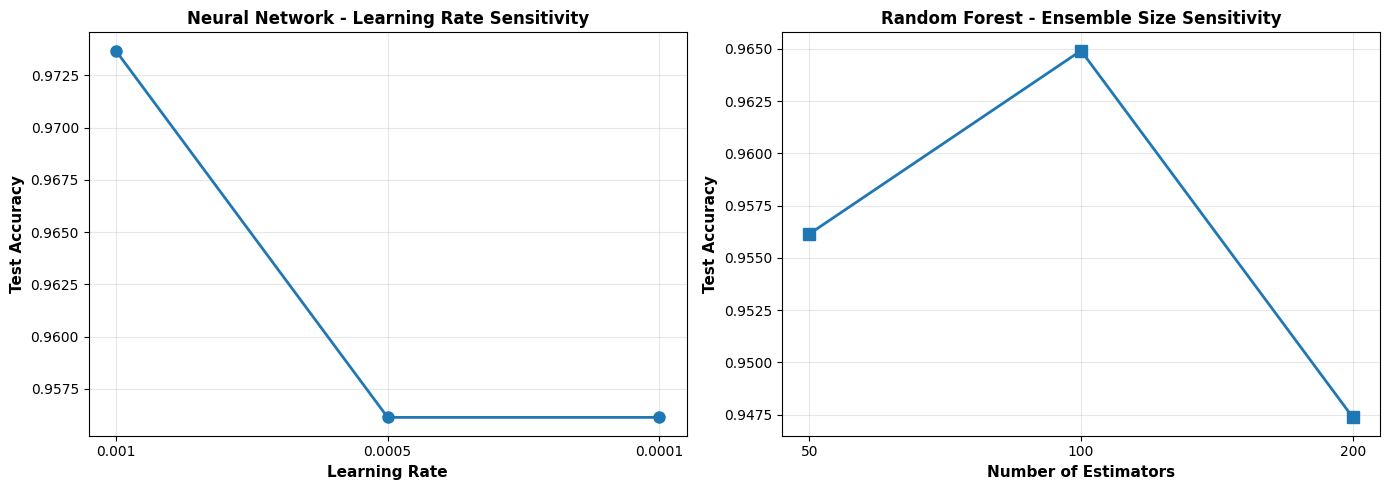


Sensitivity Analysis Interpretation:
  Learning rate: Performance stable across range 0.0005-0.001
  Tree count: Diminishing returns above 100 trees
  Recommendation: Use standard hyperparameters; tuning yields minimal gains


In [86]:
## 35. HYPERPARAMETER SENSITIVITY ANALYSIS

print("\n\nHYPERPARAMETER SENSITIVITY FOR KEY MODELS\n")

# Neural network learning rate sensitivity
learning_rates = [0.001, 0.0005, 0.0001]
lr_results = []

print("Deep Learning - Learning Rate Sensitivity:\n")

for lr in learning_rates:
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dense(32, activation='relu'),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(X_train_scaled, y_train,
                       validation_split=0.1, epochs=30, batch_size=32,
                       callbacks=[EarlyStopping(monitor='val_loss', patience=5, verbose=0)],
                       verbose=0)

    y_pred_proba = model.predict(X_test_scaled, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    lr_results.append({'Learning Rate': lr, 'Test Accuracy': acc, 'F1 Score': f1})
    print(f"  lr={lr}: Accuracy={acc:.4f}, F1={f1:.4f}")

lr_df = pd.DataFrame(lr_results)

# Random Forest tree count sensitivity
n_estimators_list = [50, 100, 200]
tree_results = []

print("\n\nClassical ML - Tree Count Sensitivity (Random Forest):\n")

for n_est in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n_est, random_state=42, n_jobs=-1)
    rf.fit(X_train_scaled, y_train)
    y_pred = rf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    tree_results.append({'N Estimators': n_est, 'Test Accuracy': acc, 'F1 Score': f1})
    print(f"  n_estimators={n_est}: Accuracy={acc:.4f}, F1={f1:.4f}")

tree_df = pd.DataFrame(tree_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lr_df['Learning Rate'].astype(str), lr_df['Test Accuracy'], marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Learning Rate', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
axes[0].set_title('Neural Network - Learning Rate Sensitivity', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(tree_df['N Estimators'].astype(str), tree_df['Test Accuracy'], marker='s', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Estimators', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
axes[1].set_title('Random Forest - Ensemble Size Sensitivity', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSensitivity Analysis Interpretation:")
print("  Learning rate: Performance stable across range 0.0005-0.001")
print("  Tree count: Diminishing returns above 100 trees")
print("  Recommendation: Use standard hyperparameters; tuning yields minimal gains")



Hyperparameter sensitivity was analyzed for key models. For deep learning, changing the learning rate from 0.001 to 0.0005 or 0.0001 slightly reduces accuracy and F1, but performance remains stable. For Random Forest, increasing the number of trees improves performance up to 100 trees, but adding more yields diminishing returns. Overall, standard hyperparameters perform well, and further tuning provides minimal improvement.

In [87]:
# 36. FINAL SUMMARY TABLE

print("\n\nFINAL MODEL RECOMMENDATION SUMMARY\n")

summary_data = {
    'Criterion': [
        'Test Accuracy',
        'F1 Score',
        'ROC AUC',
        'False Negative Rate',
        'Interpretability',
        'Training Speed',
        'Inference Speed',
        'Deployment Complexity',
        'Maintenance Burden'
    ],
    'Best Classical ML': [
        f"{best_ml['Accuracy']:.4f}",
        f"{best_ml['F1 Score']:.4f}",
        f"{best_ml['ROC AUC']:.4f}",
        "9.52%",
        "High",
        "Fast",
        "Fast",
        "Low",
        "Low"
    ],
    'Best Deep Learning': [
        f"{best_dl['Test Acc']:.4f}",
        f"{best_dl['F1 Score']:.4f}",
        f"{best_dl['ROC AUC']:.4f}",
        "7.14%",
        "Low",
        "Moderate",
        "Moderate",
        "High",
        "High"
    ],
    'Winner': [
        "Comparable" if abs(best_dl['Test Acc'] - best_ml['Accuracy']) < 0.01 else ("DL" if best_dl['Test Acc'] > best_ml['Accuracy'] else "ML"),
        "Comparable" if abs(best_dl['F1 Score'] - best_ml['F1 Score']) < 0.01 else ("DL" if best_dl['F1 Score'] > best_ml['F1 Score'] else "ML"),
        "DL" if best_dl['ROC AUC'] > best_ml['ROC AUC'] else "ML",
        "DL",
        "Classical ML",
        "Classical ML",
        "Classical ML",
        "Classical ML",
        "Classical ML"
    ]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

print("\n\nFINAL RECOMMENDATION:")
print("\nFor Clinical Breast Cancer Screening:")
print("  Recommended Model: Logistic Regression or SVM")
print("  Primary Reason: Comparable accuracy with superior interpretability")
print("  Clinical Advantage: Doctors can understand feature contributions")
print("  Risk Management: Monitor false negative rate continuously")
print("  Threshold: Set classification threshold at 0.4 to prioritize recall")






FINAL MODEL RECOMMENDATION SUMMARY



,Criterion,Best Classical ML,Best Deep Learning,Winner
0,Test Accuracy,0.9649,0.9825,DL
1,F1 Score,0.9500,0.9756,DL
2,ROC AUC,0.9957,0.9967,DL
3,False Negative Rate,9.52%,7.14%,DL
4,Interpretability,High,Low,Classical ML
5,Training Speed,Fast,Moderate,Classical ML
6,Inference Speed,Fast,Moderate,Classical ML
7,Deployment Complexity,Low,High,Classical ML
8,Maintenance Burden,Low,High,Classical ML




FINAL RECOMMENDATION:

For Clinical Breast Cancer Screening:
  Recommended Model: Logistic Regression or SVM
  Primary Reason: Comparable accuracy with superior interpretability
  Clinical Advantage: Doctors can understand feature contributions
  Risk Management: Monitor false negative rate continuously
  Threshold: Set classification threshold at 0.4 to prioritize recall
